In [552]:
# Dataset download
import kagglehub

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

import warnings

warnings.filterwarnings('ignore')

# Preprocessing and data splitting
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split

In [553]:
# Download the dataset
path = kagglehub.dataset_download("parisrohan/credit-score-classification")

# Load the CSV files in data
df = pd.read_csv(path + "/train.csv", low_memory=False)
print(f"\nDataset Dimensions: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()


Dataset Dimensions: 100000 rows × 28 columns


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


In [554]:
df.dtypes

ID                           object
Customer_ID                  object
Month                        object
Name                         object
Age                          object
SSN                          object
Occupation                   object
Annual_Income                object
Monthly_Inhand_Salary       float64
Num_Bank_Accounts             int64
Num_Credit_Card               int64
Interest_Rate                 int64
Num_of_Loan                  object
Type_of_Loan                 object
Delay_from_due_date           int64
Num_of_Delayed_Payment       object
Changed_Credit_Limit         object
Num_Credit_Inquiries        float64
Credit_Mix                   object
Outstanding_Debt             object
Credit_Utilization_Ratio    float64
Credit_History_Age           object
Payment_of_Min_Amount        object
Total_EMI_per_month         float64
Amount_invested_monthly      object
Payment_Behaviour            object
Monthly_Balance              object
Credit_Score                

ID: Represents a unique identification of an entry
Customer_ID: Represents a unique identification of a person
Month: Represents the month of the year
Name: Represents the name of a person
Age: Represents the age of the person
SSN: Represents the social security number of a person
Occupation: Represents the occupation of the person
Annual_Income: Represents the annual income of the person
Monthly_Base_Salary: Represents the monthly base salary of a person
Num_Bank_Accounts: Represents the number of bank accounts a person holds
Num_Credit_Card: Represents the number of other credit cards held by a person
Interest_Rate: Represents the interest rate on credit card
Num_of_Loan: Represents the number of loans taken from the bank
Type_of_Loan: Represents the types of loan taken by a person
Delay_from_due_date: Represents the average number of days delayed from the payment date
Num_of_delayed_Payment: Represents the average number of payments delayed by a person
Changed_Credit_Limit: Represents the percentage change in credit card limit
Num_Credit_Inquiries: Represents the number of credit card inquiries
Credit_Mix: Represents the classification of the mix of credits
Outstanding_Debt: Represents the remaining debt to be paid (in USD)
Credit_Utilization_Ratio: Represents the utilization ratio of credit card
Credit_History_Age: Represents the age of credit history of the person
Payment_of_Min_Amount: Represents whether only the minimum amount was paid by the person
Total_EMI_per_month: Represents the monthly EMI payments (in USD)
Amount_invested_monthly: Represents the monthly amount invested by the customer (in USD)
Payment_Behaviour: Represents the payment behavior of the customer (in USD)
Monthly_Balance: Represents the monthly balance amount of the customer (in USD)
Credit_Score: Represents the bracket of credit score (Poor, Standard, Good)

In [555]:
df.nunique()

ID                          100000
Customer_ID                  12500
Month                            8
Name                         10139
Age                           1788
SSN                          12501
Occupation                      16
Annual_Income                18940
Monthly_Inhand_Salary        13235
Num_Bank_Accounts              943
Num_Credit_Card               1179
Interest_Rate                 1750
Num_of_Loan                    434
Type_of_Loan                  6260
Delay_from_due_date             73
Num_of_Delayed_Payment         749
Changed_Credit_Limit          4384
Num_Credit_Inquiries          1223
Credit_Mix                       4
Outstanding_Debt             13178
Credit_Utilization_Ratio    100000
Credit_History_Age             404
Payment_of_Min_Amount            3
Total_EMI_per_month          14950
Amount_invested_monthly      91049
Payment_Behaviour                7
Monthly_Balance              98792
Credit_Score                     3
dtype: int64

In [556]:
df.duplicated().sum()

np.int64(0)

In [557]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 non-null   ob

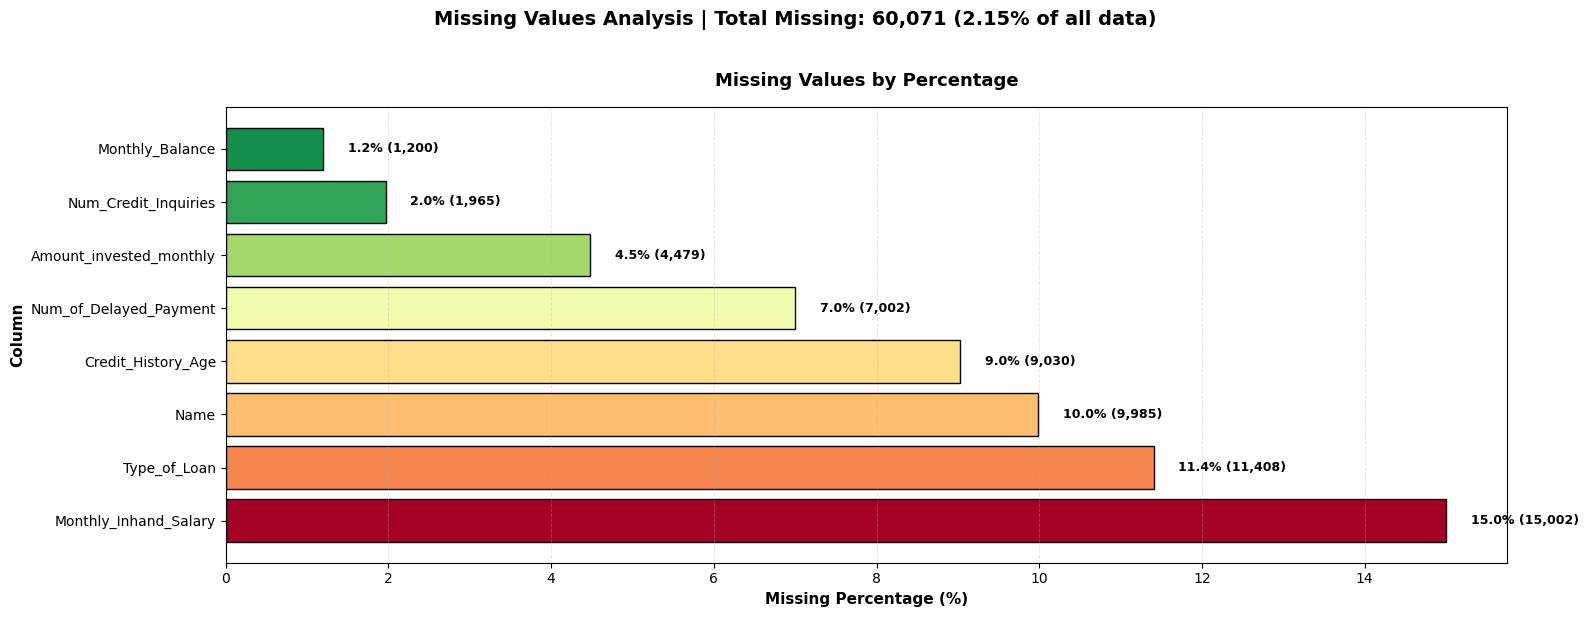


Missing Values Summary:
Total missing values: 60,071
Percentage of total data: 2.15%
Columns with missing values: 8 out of 28


In [558]:
# Create a comprehensive missing values visualization
fig, ax1 = plt.subplots(1,1, figsize=(16, 6))

# Calculate missing values
missing_count = df.isnull().sum()
missing_percentage = (missing_count / len(df)) * 100

# Filter columns with missing values
missing_df = pd.DataFrame({
    'Column': df.columns,
    'Count': missing_count,
    'Percentage': missing_percentage
})
missing_df = missing_df[missing_df['Count'] > 0].sort_values(by='Percentage', ascending=False)

# Left plot: Horizontal bar chart with percentages
colors_gradient = plt.cm.RdYlGn_r(missing_df['Percentage'] / missing_df['Percentage'].max())
bars = ax1.barh(missing_df['Column'], missing_df['Percentage'], color=colors_gradient, 
                edgecolor='black', linewidth=1)

ax1.set_xlabel('Missing Percentage (%)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Column', fontsize=11, fontweight='bold')
ax1.set_title('Missing Values by Percentage', fontsize=13, fontweight='bold', pad=15)
ax1.grid(axis='x', alpha=0.3, linestyle='--', linewidth=0.7)

# Add percentage labels on bars
for i, (bar, pct, count) in enumerate(zip(bars, missing_df['Percentage'], missing_df['Count'])):
    width = bar.get_width()
    ax1.text(width + 0.3, bar.get_y() + bar.get_height()/2, 
             f'{pct:.1f}% ({int(count):,})',
             ha='left', va='center', fontsize=9, fontweight='bold')

# Add summary statistics
total_missing = missing_count.sum()
total_cells = df.shape[0] * df.shape[1]
overall_pct = (total_missing / total_cells) * 100

fig.suptitle(f'Missing Values Analysis | Total Missing: {int(total_missing):,} ({overall_pct:.2f}% of all data)', 
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

# Display summary
print("\nMissing Values Summary:")
print(f"Total missing values: {int(total_missing):,}")
print(f"Percentage of total data: {overall_pct:.2f}%")
print(f"Columns with missing values: {len(missing_df)} out of {df.shape[1]}")

In [559]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Monthly_Inhand_Salary,84998.0,4194.170850,3183.686167,303.645417,1625.568229,3093.745000,5957.448333,15204.633333
Num_Bank_Accounts,100000.0,17.091280,117.404834,-1.000000,3.000000,6.000000,7.000000,1798.000000
Num_Credit_Card,100000.0,22.474430,129.057410,0.000000,4.000000,5.000000,7.000000,1499.000000
Interest_Rate,100000.0,72.466040,466.422621,1.000000,8.000000,13.000000,20.000000,5797.000000
Delay_from_due_date,100000.0,21.068780,14.860104,-5.000000,10.000000,18.000000,28.000000,67.000000
Num_Credit_Inquiries,98035.0,27.754251,193.177339,0.000000,3.000000,6.000000,9.000000,2597.000000
Credit_Utilization_Ratio,100000.0,32.285173,5.116875,20.000000,28.052567,32.305784,36.496663,50.000000
Total_EMI_per_month,100000.0,1403.118217,8306.041270,0.000000,30.306660,69.249473,161.224249,82331.000000


In [560]:
df.describe(exclude=np.number).T

,count,unique,top,freq
ID,100000,100000,0x1602,1
Customer_ID,100000,12500,CUS_0xd40,8
Month,100000,8,January,12500
Name,90015,10139,Langep,44
Age,100000,1788,38,2833
SSN,100000,12501,#F%$D@*&8,5572
Occupation,100000,16,_______,7062
Annual_Income,100000,18940,36585.12,16
Num_of_Loan,100000,434,3,14386
Type_of_Loan,88592,6260,Not Specified,1408


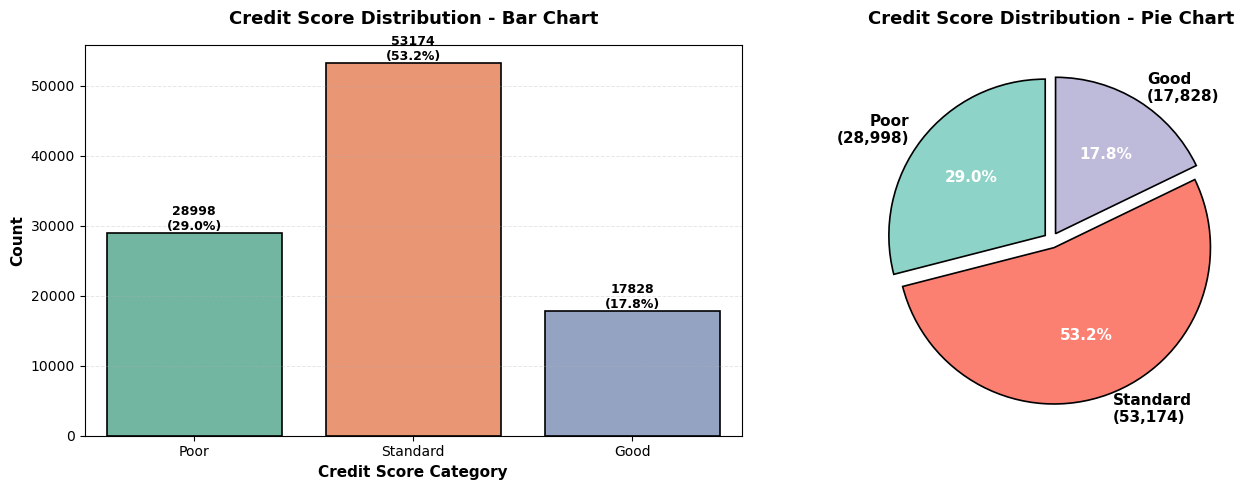


Normalized Credit Score Distribution:
Credit_Score
Good        0.17828
Poor        0.28998
Standard    0.53174
Name: proportion, dtype: float64


In [561]:
# Create a comprehensive visualization for Credit Score distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Get value counts in the correct order
credit_order = ['Poor', 'Standard', 'Good']
credit_counts = df['Credit_Score'].value_counts()[credit_order]
total = len(df['Credit_Score'])

# Left plot: Bar chart
sns.countplot(data=df, x='Credit_Score', ax=ax1, palette='Set2', 
              edgecolor='black', linewidth=1.2, order=credit_order)

ax1.set_title('Credit Score Distribution - Bar Chart', fontsize=13, fontweight='bold', pad=15)
ax1.set_xlabel('Credit Score Category', fontsize=11, fontweight='bold')
ax1.set_ylabel('Count', fontsize=11, fontweight='bold')
ax1.tick_params(axis='both', labelsize=10)
ax1.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.7)

# Add combined count and percentage labels on bars
for patch in ax1.patches:
    height = patch.get_height()
    percentage = (height / total) * 100
    ax1.text(patch.get_x() + patch.get_width()/2., height,
            f'{int(height)}\n({percentage:.1f}%)', 
            ha='center', va='bottom', 
            fontsize=9, fontweight='bold')

# Right plot: Pie chart
colors = ['#8dd3c7', '#fb8072', '#bebada']  # Set2 palette colors
explode = (0.05, 0.05, 0.05)  # Slightly separate slices

wedges, texts, autotexts = ax2.pie(credit_counts, labels=credit_order, autopct='%1.1f%%',
                                     colors=colors, explode=explode, startangle=90,
                                     textprops={'fontsize': 10, 'fontweight': 'bold'},
                                     wedgeprops={'edgecolor': 'black', 'linewidth': 1.2})

# Enhance autopct text
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')

# Add count to labels
for i, (label, count) in enumerate(zip(texts, credit_counts)):
    label.set_fontsize(11)
    label.set_fontweight('bold')
    label.set_text(f'{label.get_text()}\n({count:,})')

ax2.set_title('Credit Score Distribution - Pie Chart', fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

# Display normalized value counts
print("\nNormalized Credit Score Distribution:")
print(df['Credit_Score'].value_counts(normalize=True).sort_index())

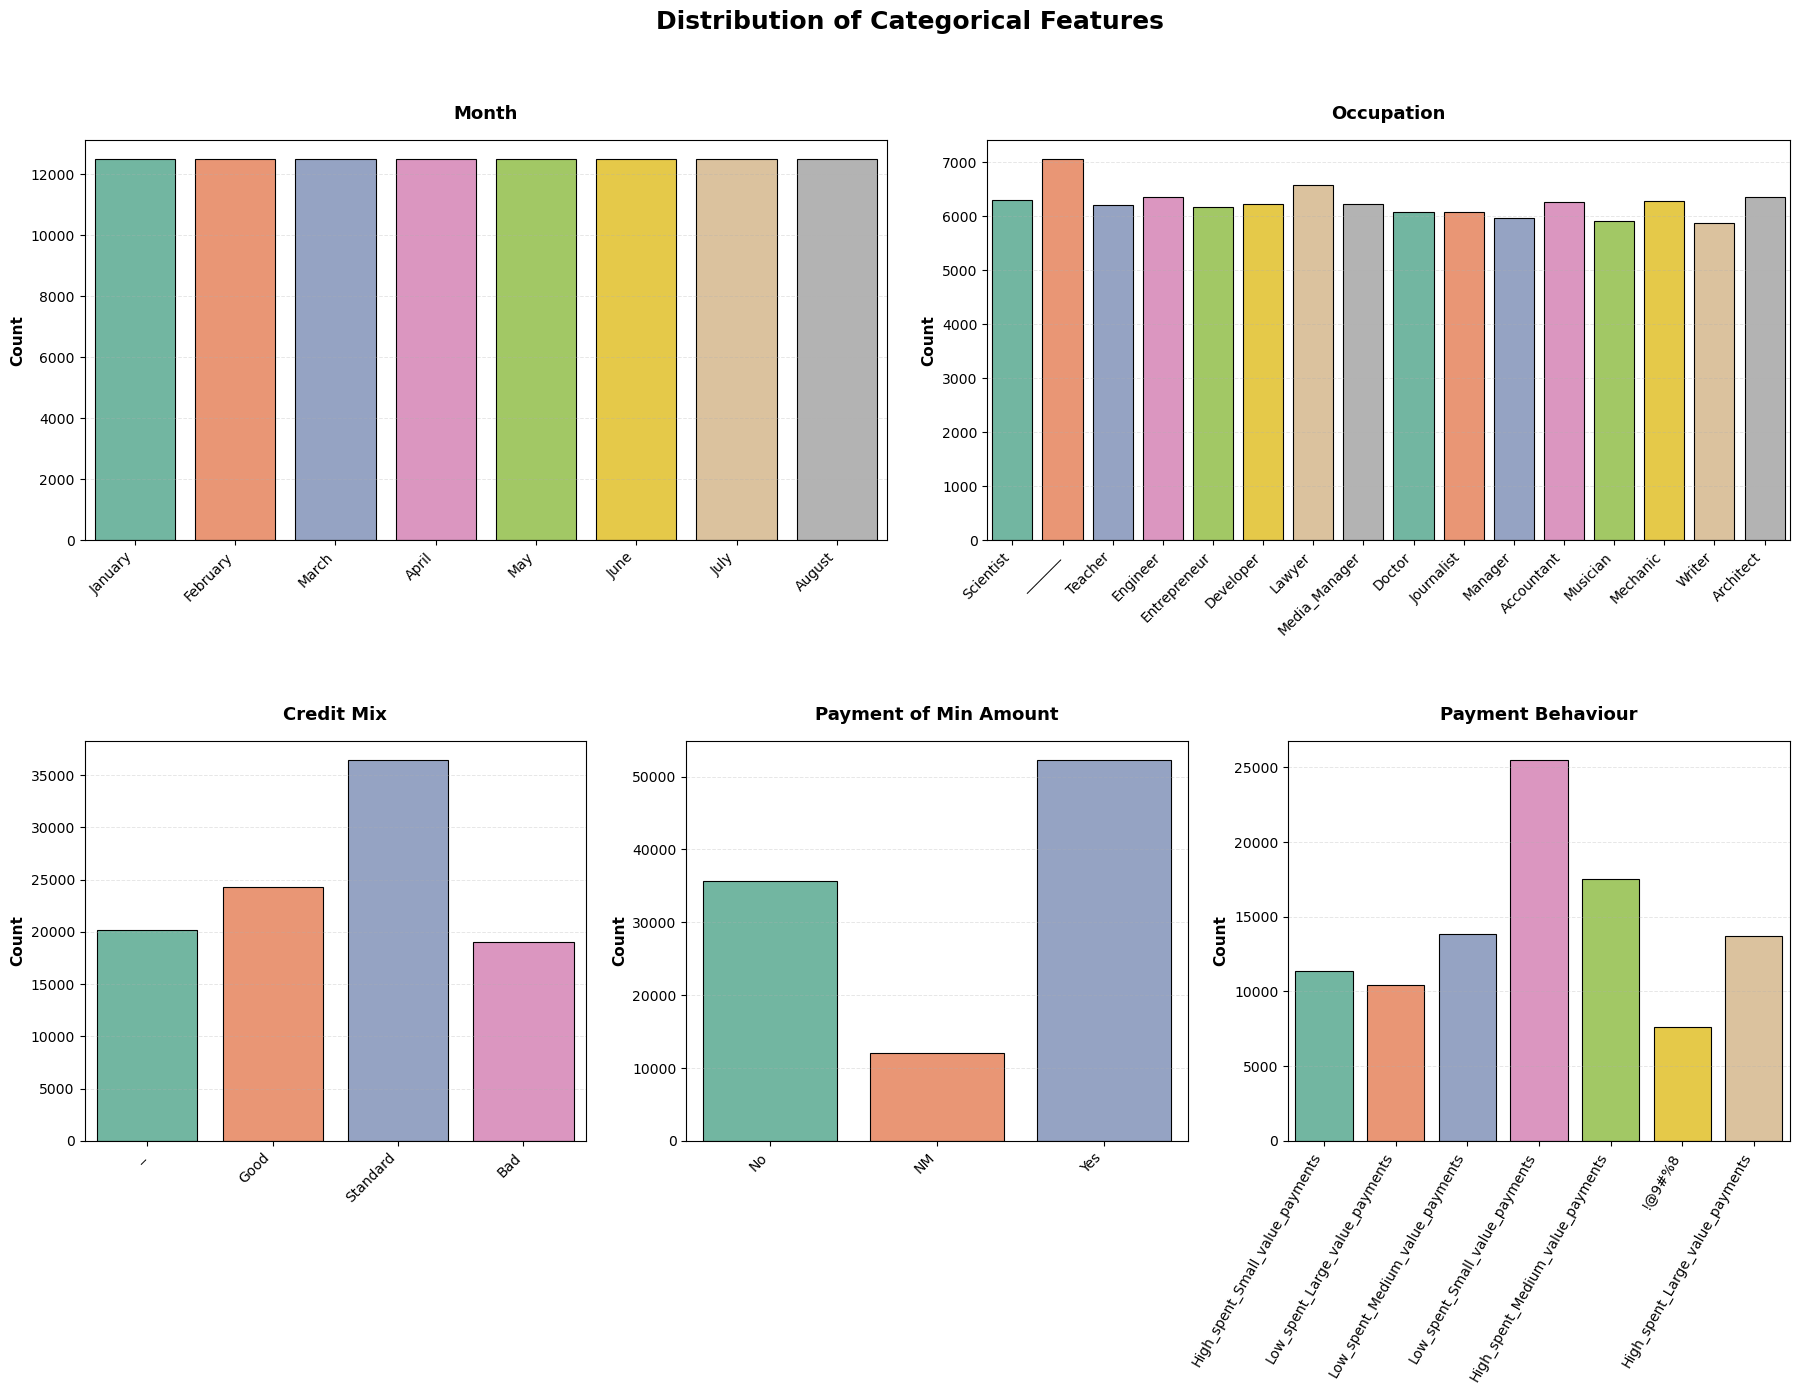

In [562]:
# Create a single figure with subplots for categorical variables
import matplotlib.gridspec as gridspec

columns = ['Month', 'Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']

fig = plt.figure(figsize=(22, 13))
gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.5, wspace=0.5)

# Row 1: 2 plots centered
ax1 = fig.add_subplot(gs[0, 0:3])
ax2 = fig.add_subplot(gs[0, 3:6])

# Row 2: 3 plots
ax3 = fig.add_subplot(gs[1, 0:2])
ax4 = fig.add_subplot(gs[1, 2:4])
ax5 = fig.add_subplot(gs[1, 4:6])

axes_list = [ax1, ax2, ax3, ax4, ax5]

fig.suptitle('Distribution of Categorical Features', fontsize=18, fontweight='bold', y=0.98)

for idx, col in enumerate(columns):
    ax = axes_list[idx]
    sns.countplot(data=df, x=col, ax=ax, palette='Set2', edgecolor='black', linewidth=0.8)
    ax.set_title(f'{col.replace("_", " ")}', fontsize=13, fontweight='bold', pad=15)
    ax.set_xlabel('')
    ax.set_ylabel('Count', fontsize=11, fontweight='bold')
    
    # Special handling for Payment_Behaviour with long labels
    if col == 'Payment_Behaviour':
        ax.tick_params(axis='x', rotation=60, labelsize=10)
        # Align labels to the right for better readability
        for label in ax.get_xticklabels():
            label.set_ha('right')
            label.set_fontweight('medium')
    else:
        ax.tick_params(axis='x', rotation=45, labelsize=10)
        for label in ax.get_xticklabels():
            label.set_ha('right')
    
    ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.7)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

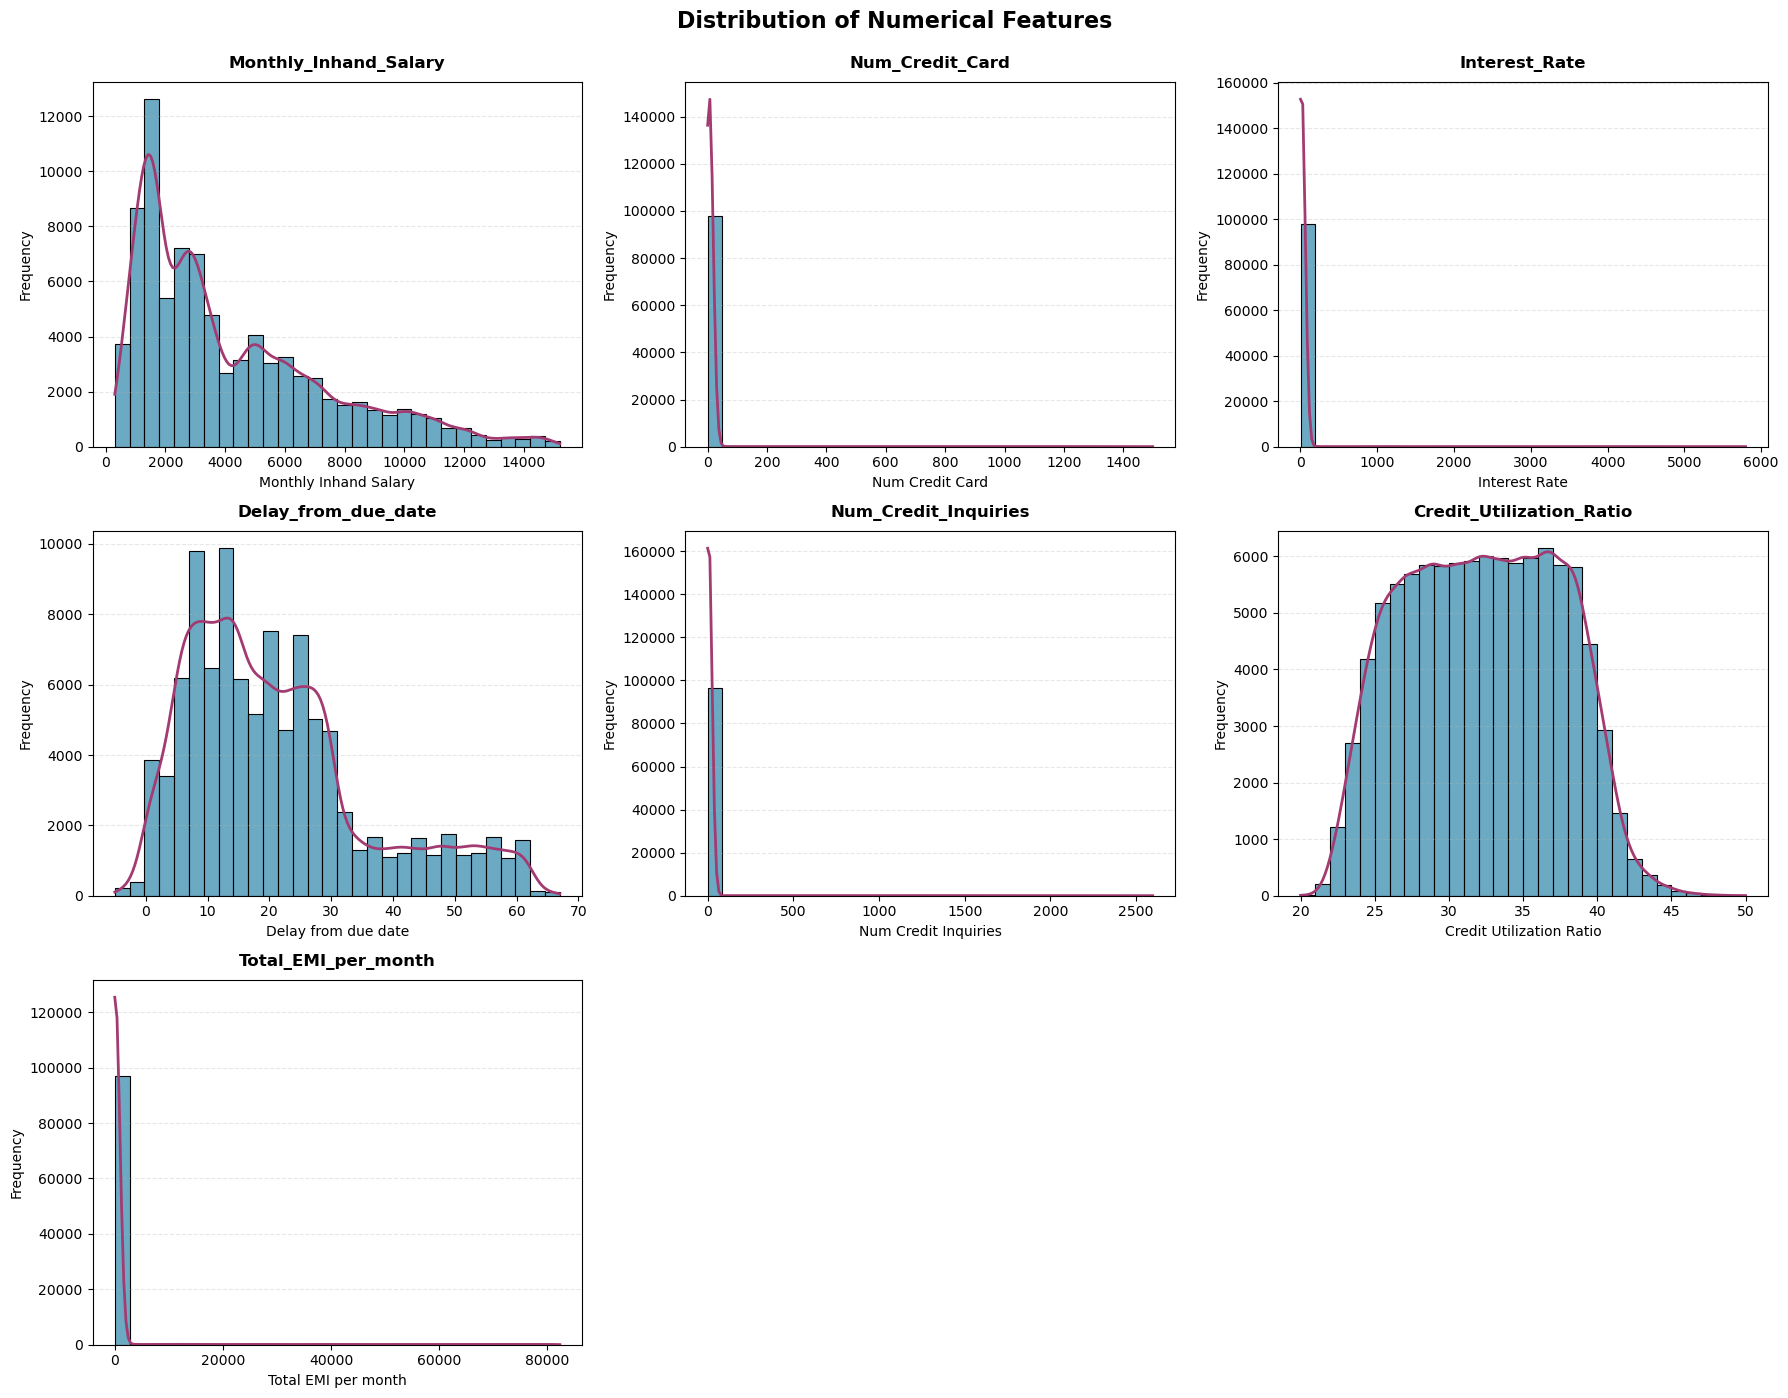

In [563]:
# Create a single figure with subplots for numerical variables
columns = ['Monthly_Inhand_Salary', 'Num_Credit_Card', 'Interest_Rate', 'Delay_from_due_date', 
           'Num_Credit_Inquiries', 'Credit_Utilization_Ratio', 'Total_EMI_per_month']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('Distribution of Numerical Features', fontsize=16, fontweight='bold', y=0.995)

axes = axes.flatten()

for idx, col in enumerate(columns):
    sns.histplot(data=df, x=col, kde=True, ax=axes[idx], color='#2E86AB', 
                 edgecolor='black', linewidth=0.8, bins=30, alpha=0.7)
    axes[idx].set_title(f'{col}', fontsize=12, fontweight='bold', pad=10)
    axes[idx].set_xlabel(col.replace('_', ' '), fontsize=10)
    axes[idx].set_ylabel('Frequency', fontsize=10)
    axes[idx].grid(axis='y', alpha=0.3, linestyle='--')
    
    # Style KDE line
    for line in axes[idx].lines:
        line.set_color('#A23B72')
        line.set_linewidth(2)

# Hide the extra subplots
for idx in range(len(columns), 9):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

In [564]:
df['Type_of_Loan'].value_counts().head(10)

Type_of_Loan
Not Specified                      1408
Credit-Builder Loan                1280
Personal Loan                      1272
Debt Consolidation Loan            1264
Student Loan                       1240
Payday Loan                        1200
Mortgage Loan                      1176
Auto Loan                          1152
Home Equity Loan                   1136
Personal Loan, and Student Loan     320
Name: count, dtype: int64

ID, Name and SSN (Not useful)
Age, Annual_Income, Num_of_Loan, Num_of_Delayed_Payment, Changed_Credit_Limit, Amount_invested_monthly, Outstanding_Debt Credit_Mix, Monthly_Balance Numerical but show as catogery (need to be fixed)
Occupation, CreditMix has value "__"
Data contains outliers
Num_Credit_Card has zeros
Type_of_Loan Need to rewrite as 8 columns
Num_Bank_Accounts contains negative values
Credit_History_Age,Payment_of_Min_Amount,Payment_Behaviour,'Credit_Mix' (needs Feature Engineering)
Target Columns is Imbalanced
A lot of missing data

In [565]:
cols_to_drop = ['ID', 'Name', 'SSN']

df.drop(cols_to_drop, axis=1, inplace=True)

In [566]:
cols_to_fix= [
    'Age',
    'Annual_Income',
    'Num_of_Loan',
    'Num_of_Delayed_Payment',
    'Changed_Credit_Limit',
    'Outstanding_Debt',
    'Amount_invested_monthly',
    'Monthly_Balance'
]

for col in cols_to_fix:
    df[col] = df[col].str.replace('_', '')
    try:
        df[col] = df[col].astype('float')
    except:
        continue

df[cols_to_fix].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Age                      100000 non-null  float64
 1   Annual_Income            100000 non-null  float64
 2   Num_of_Loan              100000 non-null  float64
 3   Num_of_Delayed_Payment   92998 non-null   float64
 4   Changed_Credit_Limit     100000 non-null  object 
 5   Outstanding_Debt         100000 non-null  float64
 6   Amount_invested_monthly  95521 non-null   float64
 7   Monthly_Balance          98800 non-null   float64
dtypes: float64(7), object(1)
memory usage: 6.1+ MB


In [567]:
df['Changed_Credit_Limit'] = df['Changed_Credit_Limit'].replace('', np.nan)
df['Changed_Credit_Limit'] = df['Changed_Credit_Limit'].astype('float')

df[cols_to_fix].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Age                      100000 non-null  float64
 1   Annual_Income            100000 non-null  float64
 2   Num_of_Loan              100000 non-null  float64
 3   Num_of_Delayed_Payment   92998 non-null   float64
 4   Changed_Credit_Limit     97909 non-null   float64
 5   Outstanding_Debt         100000 non-null  float64
 6   Amount_invested_monthly  95521 non-null   float64
 7   Monthly_Balance          98800 non-null   float64
dtypes: float64(8)
memory usage: 6.1 MB


In [568]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,100000.0,1.106497e+02,6.862447e+02,-5.000000e+02,24.000000,33.000000,42.000000,8.698000e+03
Annual_Income,100000.0,1.764157e+05,1.429618e+06,7.005930e+03,19457.500000,37578.610000,72790.920000,2.419806e+07
Monthly_Inhand_Salary,84998.0,4.194171e+03,3.183686e+03,3.036454e+02,1625.568229,3093.745000,5957.448333,1.520463e+04
Num_Bank_Accounts,100000.0,1.709128e+01,1.174048e+02,-1.000000e+00,3.000000,6.000000,7.000000,1.798000e+03
Num_Credit_Card,100000.0,2.247443e+01,1.290574e+02,0.000000e+00,4.000000,5.000000,7.000000,1.499000e+03
Interest_Rate,100000.0,7.246604e+01,4.664226e+02,1.000000e+00,8.000000,13.000000,20.000000,5.797000e+03
Num_of_Loan,100000.0,3.009960e+00,6.264788e+01,-1.000000e+02,1.000000,3.000000,5.000000,1.496000e+03
Delay_from_due_date,100000.0,2.106878e+01,1.486010e+01,-5.000000e+00,10.000000,18.000000,28.000000,6.700000e+01
Num_of_Delayed_Payment,92998.0,3.092334e+01,2.260319e+02,-3.000000e+00,9.000000,14.000000,18.000000,4.397000e+03
Changed_Credit_Limit,97909.0,1.038903e+01,6.789496e+00,-6.490000e+00,5.320000,9.400000,14.870000,3.697000e+01


In [569]:
columns_to_fix = ['Age', 'Num_Bank_Accounts', 'Num_of_Loan', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit']

df[columns_to_fix] = df[columns_to_fix].applymap(lambda x: np.nan if x < 0 else x)

df[cols_to_fix].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,99114.0,1.161084e+02,6.868613e+02,1.400000e+01,25.000000,33.000000,42.000000,8.698000e+03
Annual_Income,100000.0,1.764157e+05,1.429618e+06,7.005930e+03,19457.500000,37578.610000,72790.920000,2.419806e+07
Num_of_Loan,96124.0,7.163622e+00,6.031492e+01,0.000000e+00,2.000000,3.000000,5.000000,1.496000e+03
Num_of_Delayed_Payment,92354.0,3.115052e+01,2.268022e+02,0.000000e+00,9.000000,14.000000,18.000000,4.397000e+03
Changed_Credit_Limit,96323.0,1.059904e+01,6.639966e+00,0.000000e+00,5.570000,9.520000,15.010000,3.697000e+01
Outstanding_Debt,100000.0,1.426220e+03,1.155129e+03,2.300000e-01,566.072500,1166.155000,1945.962500,4.998070e+03
Amount_invested_monthly,95521.0,6.374130e+02,2.043319e+03,0.000000e+00,74.534002,135.925682,265.731733,1.000000e+04
Monthly_Balance,98800.0,-3.036437e+22,3.181295e+24,-3.333333e+26,270.092209,336.719190,470.220186,1.602041e+03


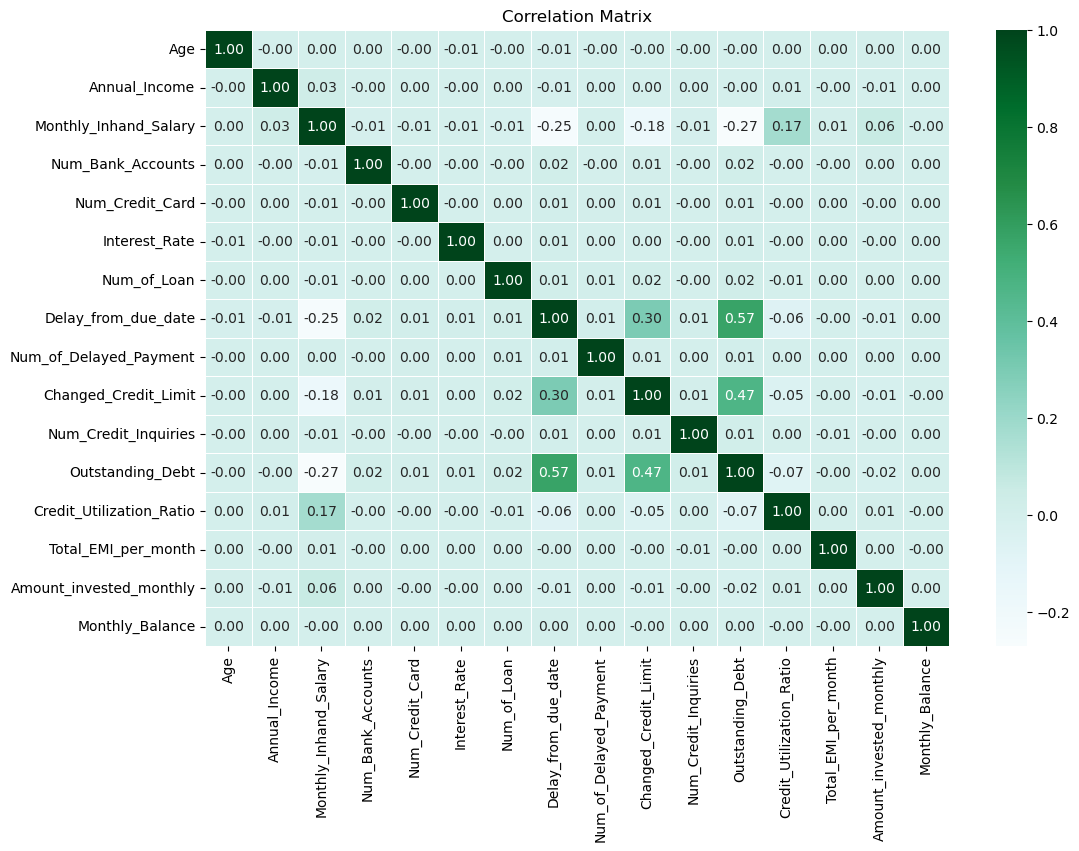

In [570]:
corr_matrix = df.select_dtypes(include=['float64', 'int64']).corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='BuGn', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix')
plt.show()

In [571]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 25 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Customer_ID               100000 non-null  object 
 1   Month                     100000 non-null  object 
 2   Age                       99114 non-null   float64
 3   Occupation                100000 non-null  object 
 4   Annual_Income             100000 non-null  float64
 5   Monthly_Inhand_Salary     84998 non-null   float64
 6   Num_Bank_Accounts         99979 non-null   float64
 7   Num_Credit_Card           100000 non-null  int64  
 8   Interest_Rate             100000 non-null  int64  
 9   Num_of_Loan               96124 non-null   float64
 10  Type_of_Loan              88592 non-null   object 
 11  Delay_from_due_date       100000 non-null  int64  
 12  Num_of_Delayed_Payment    92354 non-null   float64
 13  Changed_Credit_Limit      96323 non-null   fl

In [572]:
data_categorical = df[df.select_dtypes(include=['object']).columns]
data_categorical.head()

,Customer_ID,Month,Occupation,Type_of_Loan,Credit_Mix,Credit_History_Age,Payment_of_Min_Amount,Payment_Behaviour,Credit_Score
0,CUS_0xd40,January,Scientist,"Auto Loan, Credit-Builder Loan, Personal Loan,...",_,22 Years and 1 Months,No,High_spent_Small_value_payments,Good
1,CUS_0xd40,February,Scientist,"Auto Loan, Credit-Builder Loan, Personal Loan,...",Good,NaN,No,Low_spent_Large_value_payments,Good
2,CUS_0xd40,March,Scientist,"Auto Loan, Credit-Builder Loan, Personal Loan,...",Good,22 Years and 3 Months,No,Low_spent_Medium_value_payments,Good
3,CUS_0xd40,April,Scientist,"Auto Loan, Credit-Builder Loan, Personal Loan,...",Good,22 Years and 4 Months,No,Low_spent_Small_value_payments,Good
4,CUS_0xd40,May,Scientist,"Auto Loan, Credit-Builder Loan, Personal Loan,...",Good,22 Years and 5 Months,No,High_spent_Medium_value_payments,Good


In [573]:
for i in df.select_dtypes(include='object').columns.tolist():
    print(f'{i} value counts:')
    print(df[i].value_counts())
    print()

Customer_ID value counts:
Customer_ID
CUS_0xd40     8
CUS_0x9bf4    8
CUS_0x5ae3    8
CUS_0xbe9a    8
CUS_0x4874    8
             ..
CUS_0x2eb4    8
CUS_0x7863    8
CUS_0x9d89    8
CUS_0xc045    8
CUS_0x942c    8
Name: count, Length: 12500, dtype: int64

Month value counts:
Month
January     12500
February    12500
March       12500
April       12500
May         12500
June        12500
July        12500
August      12500
Name: count, dtype: int64

Occupation value counts:
Occupation
_______          7062
Lawyer           6575
Architect        6355
Engineer         6350
Scientist        6299
Mechanic         6291
Accountant       6271
Developer        6235
Media_Manager    6232
Teacher          6215
Entrepreneur     6174
Doctor           6087
Journalist       6085
Manager          5973
Musician         5911
Writer           5885
Name: count, dtype: int64

Type_of_Loan value counts:
Type_of_Loan
Not Specified                                                                               

In [574]:
def to_months(val):
    if pd.isnull(val):
        return val

    x = int(val.split(' ')[0])
    y = int(val.split(' ')[3])

    return x * 12 + y

df['Credit_History_Age'] = df['Credit_History_Age'].apply(lambda x: to_months(x)).astype(float)

In [575]:
df['Payment_of_Min_Amount'].replace('NM', 'No', inplace=True)

In [576]:
df['Payment_Behaviour']= df['Payment_Behaviour'].replace('!@9#%8', np.nan)

In [577]:
df['Occupation'] = df['Occupation'].replace('_______', np.nan)

In [578]:
df['Credit_Mix']= df['Credit_Mix'].replace('_', np.nan)

In [579]:
df['Customer_ID'] = df['Customer_ID'].apply(lambda x: int(x[4:], 16))

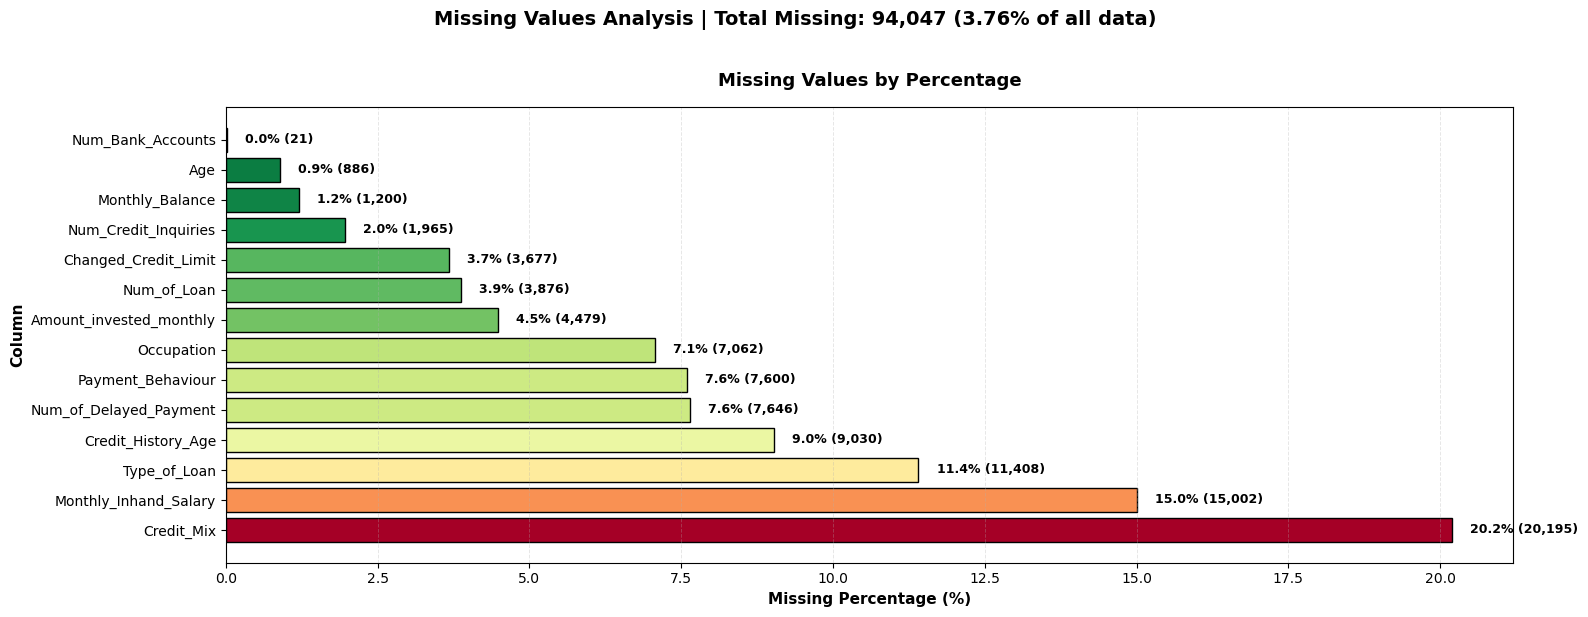


Missing Values Summary:
Total missing values: 94,047
Percentage of total data: 3.76%
Columns with missing values: 14 out of 25


In [580]:
# Create a comprehensive missing values visualization
fig, ax1 = plt.subplots(1,1, figsize=(16, 6))

# Calculate missing values
missing_count = df.isnull().sum()
missing_percentage = (missing_count / len(df)) * 100

# Filter columns with missing values
missing_df = pd.DataFrame({
    'Column': df.columns,
    'Count': missing_count,
    'Percentage': missing_percentage
})
missing_df = missing_df[missing_df['Count'] > 0].sort_values(by='Percentage', ascending=False)

# Left plot: Horizontal bar chart with percentages
colors_gradient = plt.cm.RdYlGn_r(missing_df['Percentage'] / missing_df['Percentage'].max())
bars = ax1.barh(missing_df['Column'], missing_df['Percentage'], color=colors_gradient, 
                edgecolor='black', linewidth=1)

ax1.set_xlabel('Missing Percentage (%)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Column', fontsize=11, fontweight='bold')
ax1.set_title('Missing Values by Percentage', fontsize=13, fontweight='bold', pad=15)
ax1.grid(axis='x', alpha=0.3, linestyle='--', linewidth=0.7)

# Add percentage labels on bars
for i, (bar, pct, count) in enumerate(zip(bars, missing_df['Percentage'], missing_df['Count'])):
    width = bar.get_width()
    ax1.text(width + 0.3, bar.get_y() + bar.get_height()/2, 
             f'{pct:.1f}% ({int(count):,})',
             ha='left', va='center', fontsize=9, fontweight='bold')

# Add summary statistics
total_missing = missing_count.sum()
total_cells = df.shape[0] * df.shape[1]
overall_pct = (total_missing / total_cells) * 100

fig.suptitle(f'Missing Values Analysis | Total Missing: {int(total_missing):,} ({overall_pct:.2f}% of all data)', 
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

# Display summary
print("\nMissing Values Summary:")
print(f"Total missing values: {int(total_missing):,}")
print(f"Percentage of total data: {overall_pct:.2f}%")
print(f"Columns with missing values: {len(missing_df)} out of {df.shape[1]}")

In [581]:
df.isna().sum()

Customer_ID                     0
Month                           0
Age                           886
Occupation                   7062
Annual_Income                   0
Monthly_Inhand_Salary       15002
Num_Bank_Accounts              21
Num_Credit_Card                 0
Interest_Rate                   0
Num_of_Loan                  3876
Type_of_Loan                11408
Delay_from_due_date             0
Num_of_Delayed_Payment       7646
Changed_Credit_Limit         3677
Num_Credit_Inquiries         1965
Credit_Mix                  20195
Outstanding_Debt                0
Credit_Utilization_Ratio        0
Credit_History_Age           9030
Payment_of_Min_Amount           0
Total_EMI_per_month             0
Amount_invested_monthly      4479
Payment_Behaviour            7600
Monthly_Balance              1200
Credit_Score                    0
dtype: int64

In [582]:
def fill_na_cat(data, val):
    nan_idx = list(data[val][data[val].isnull()].index)

    for i in nan_idx:
        val_pred = data[val][data['Customer_ID'] == data.iloc[i]['Customer_ID']].mode()[0]
        if not pd.isna(val_pred):
            data.loc[i, val] = val_pred
        else:
            data.loc[i, val] = data[val].mode()[0]

    return list(data[val])

In [583]:
missing_cat_cols = set(missing_df['Column'].tolist()).intersection(df.select_dtypes(include='object').columns.tolist())
missing_cat_cols

{'Credit_Mix', 'Occupation', 'Payment_Behaviour', 'Type_of_Loan'}

In [584]:
missing_cat_cols.remove('Type_of_Loan')

for col in missing_cat_cols:
    df[col] = fill_na_cat(df, col)
    print(f'Filled {col} column')

Filled Credit_Mix column
Filled Payment_Behaviour column
Filled Occupation column


In [585]:
def fill_na_num(data, val):
    nan_idx = list(data[val][data[val].isnull()].index)

    for i in nan_idx:
        val_pred = data[val][data['Customer_ID'] == data.iloc[i]['Customer_ID']].median()

        if not pd.isna(val_pred):
            data.loc[i, val] = val_pred
        else:
            data.loc[i, val] = data[val].median()

    return data[val]

In [586]:
missing_num_cols = set(missing_df['Column'].tolist()).intersection(df.select_dtypes(exclude='object').columns.tolist())

for col in missing_num_cols:
    df[col] = fill_na_num(df, col)
    print(f'Filled {col} column')

Filled Credit_History_Age column
Filled Monthly_Balance column
Filled Monthly_Inhand_Salary column
Filled Age column
Filled Num_Bank_Accounts column
Filled Amount_invested_monthly column
Filled Changed_Credit_Limit column
Filled Num_Credit_Inquiries column
Filled Num_of_Loan column
Filled Num_of_Delayed_Payment column


In [587]:
df.isna().sum()

Customer_ID                     0
Month                           0
Age                             0
Occupation                      0
Annual_Income                   0
Monthly_Inhand_Salary           0
Num_Bank_Accounts               0
Num_Credit_Card                 0
Interest_Rate                   0
Num_of_Loan                     0
Type_of_Loan                11408
Delay_from_due_date             0
Num_of_Delayed_Payment          0
Changed_Credit_Limit            0
Num_Credit_Inquiries            0
Credit_Mix                      0
Outstanding_Debt                0
Credit_Utilization_Ratio        0
Credit_History_Age              0
Payment_of_Min_Amount           0
Total_EMI_per_month             0
Amount_invested_monthly         0
Payment_Behaviour               0
Monthly_Balance                 0
Credit_Score                    0
dtype: int64

In [588]:
loan_types = {}

for idx, row in df.iterrows():
    vals = row['Type_of_Loan']
    if pd.isnull(vals): continue

    vals = vals.replace('and', '').split(', ')
    for val in vals:
        val = val.strip()
        loan_types[val] = loan_types.get(val, 0) + 1

for k, v in loan_types.items():
    print(f'{k}: {v}')

Auto Loan: 37992
Credit-Builder Loan: 40440
Personal Loan: 38888
Home Equity Loan: 39104
Not Specified: 39616
Mortgage Loan: 38936
Student Loan: 38968
Debt Consolidation Loan: 38776
Payday Loan: 40568


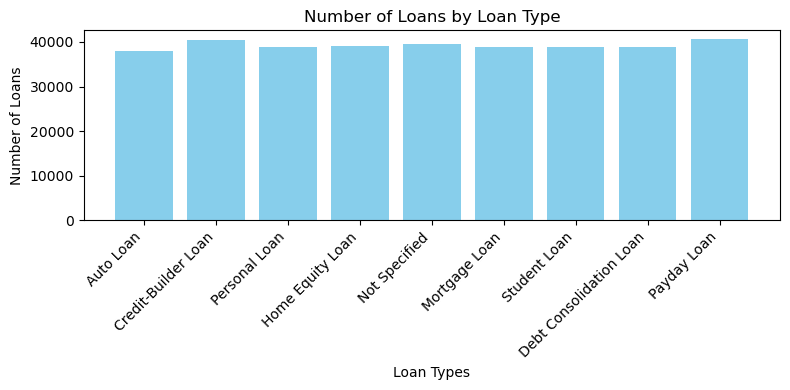

In [589]:
plt.figure(figsize=(8, 4))
plt.bar(loan_types.keys(), loan_types.values(), color='skyblue')
plt.xlabel('Loan Types')
plt.ylabel('Number of Loans')
plt.title('Number of Loans by Loan Type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [590]:
df['Type_of_Loan'].isna().sum() / len(df) * 100

np.float64(11.408)

In [591]:
df.dropna(inplace=True)

In [592]:
col_map = {True: 1, False: 0}

for i in list(loan_types.keys()):
    df[i] = df['Type_of_Loan'].str.contains(i).map(col_map)

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 88592 entries, 0 to 99999
Data columns (total 34 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_ID               88592 non-null  int64  
 1   Month                     88592 non-null  object 
 2   Age                       88592 non-null  float64
 3   Occupation                88592 non-null  object 
 4   Annual_Income             88592 non-null  float64
 5   Monthly_Inhand_Salary     88592 non-null  float64
 6   Num_Bank_Accounts         88592 non-null  float64
 7   Num_Credit_Card           88592 non-null  int64  
 8   Interest_Rate             88592 non-null  int64  
 9   Num_of_Loan               88592 non-null  float64
 10  Type_of_Loan              88592 non-null  object 
 11  Delay_from_due_date       88592 non-null  int64  
 12  Num_of_Delayed_Payment    88592 non-null  float64
 13  Changed_Credit_Limit      88592 non-null  float64
 14  Num_Credit_

In [593]:
df.drop(['Type_of_Loan', 'Not Specified'], axis=1, inplace=True)

In [594]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 88592 entries, 0 to 99999
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_ID               88592 non-null  int64  
 1   Month                     88592 non-null  object 
 2   Age                       88592 non-null  float64
 3   Occupation                88592 non-null  object 
 4   Annual_Income             88592 non-null  float64
 5   Monthly_Inhand_Salary     88592 non-null  float64
 6   Num_Bank_Accounts         88592 non-null  float64
 7   Num_Credit_Card           88592 non-null  int64  
 8   Interest_Rate             88592 non-null  int64  
 9   Num_of_Loan               88592 non-null  float64
 10  Delay_from_due_date       88592 non-null  int64  
 11  Num_of_Delayed_Payment    88592 non-null  float64
 12  Changed_Credit_Limit      88592 non-null  float64
 13  Num_Credit_Inquiries      88592 non-null  float64
 14  Credit_Mix 

In [595]:
y = df['Credit_Score']
df = df.drop('Credit_Score', axis=1)
df['Credit_Score'] = y

In [596]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns[1:-8].tolist()
len(num_cols)

17

In [597]:
num_cols

['Age',
 'Annual_Income',
 'Monthly_Inhand_Salary',
 'Num_Bank_Accounts',
 'Num_Credit_Card',
 'Interest_Rate',
 'Num_of_Loan',
 'Delay_from_due_date',
 'Num_of_Delayed_Payment',
 'Changed_Credit_Limit',
 'Num_Credit_Inquiries',
 'Outstanding_Debt',
 'Credit_Utilization_Ratio',
 'Credit_History_Age',
 'Total_EMI_per_month',
 'Amount_invested_monthly',
 'Monthly_Balance']

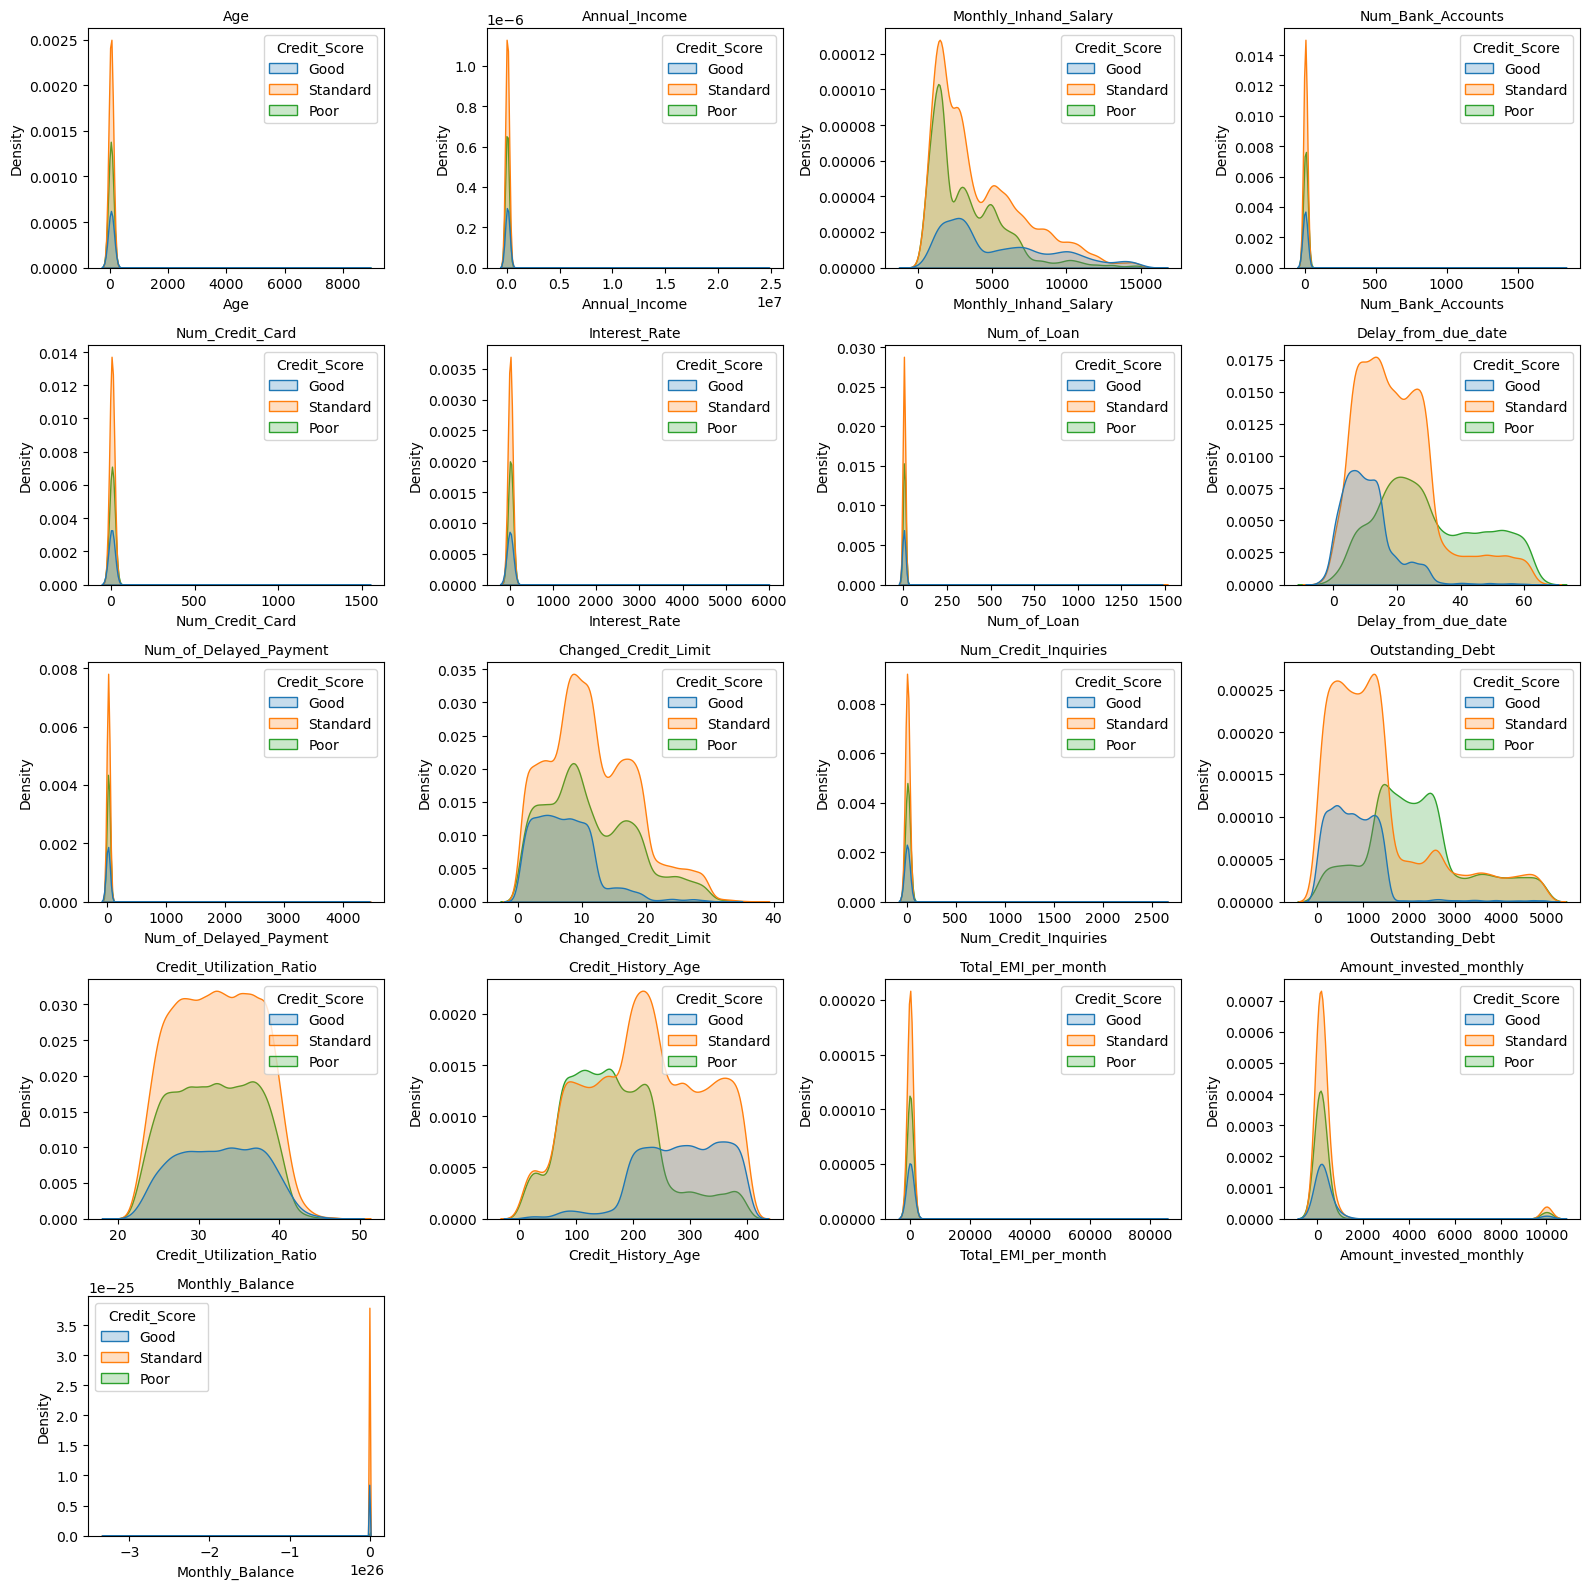

In [598]:
plt.figure(figsize=(16, 16))

for ax, col in enumerate(num_cols):
    plt.subplot(5, 4, ax + 1)
    plt.title(col, fontsize=10)
    sns.kdeplot(x=df[col], shade=True, hue=df['Credit_Score'])

plt.tight_layout()
plt.show()

In [599]:
def outlier_thresholds(data, col_name):
    Q1 = data[col_name].quantile(0.25)
    Q3 = data[col_name].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    return lower_limit, upper_limit

def check_outlier(data, col_name):
    lower_limit, upper_limit = outlier_thresholds(data, col_name)

    outliers = data[(data[col_name] > upper_limit) | (data[col_name] < lower_limit)]
    percentage_outliers = (len(outliers) / len(data)) * 100

    return outliers.any(axis=None), round(percentage_outliers, 2)

In [600]:
outlier_rows = []

for col in num_cols:
    has_outliers, percentage = check_outlier(df, col)
    outlier_rows.append({
        'Column': col,
        'Has_Outliers': has_outliers,
        'Percentage': percentage
    })

outlier_results = pd.DataFrame(outlier_rows)
outlier_results = outlier_results[outlier_results['Has_Outliers']]
outlier_results = outlier_results[outlier_results['Percentage'] > 1]
outlier_results = outlier_results.sort_values(by='Percentage')
outlier_results

,Column,Has_Outliers,Percentage
3,Num_Bank_Accounts,True,1.31
10,Num_Credit_Inquiries,True,1.64
0,Age,True,1.88
5,Interest_Rate,True,2.05
4,Num_Credit_Card,True,2.24
2,Monthly_Inhand_Salary,True,2.31
1,Annual_Income,True,2.94
7,Delay_from_due_date,True,3.27
11,Outstanding_Debt,True,3.44
14,Total_EMI_per_month,True,6.55


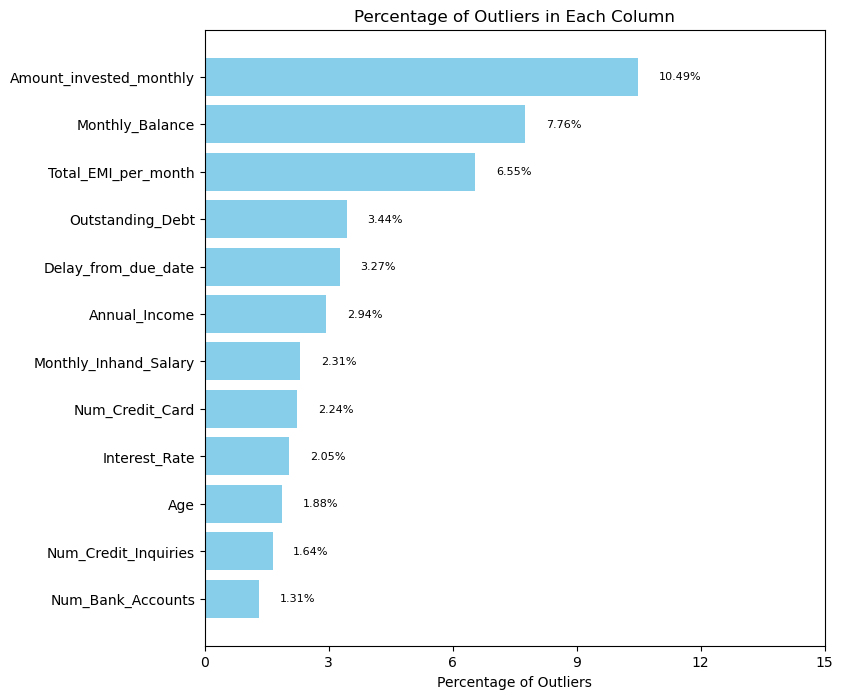

In [601]:
plt.figure(figsize=(8, 8))
bars = plt.barh(outlier_results['Column'], outlier_results['Percentage'], color='skyblue')
plt.xlabel('Percentage of Outliers')
plt.title('Percentage of Outliers in Each Column')
plt.xticks(np.arange(0, 16, 3))

for bar, label in zip(bars, outlier_results['Percentage']):
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2, f'{label:.2f}%', va='center', fontsize=8)

plt.show()

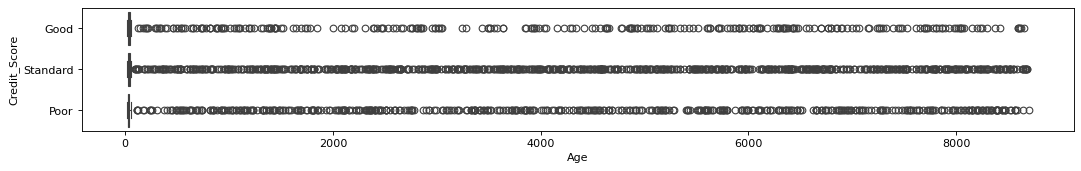

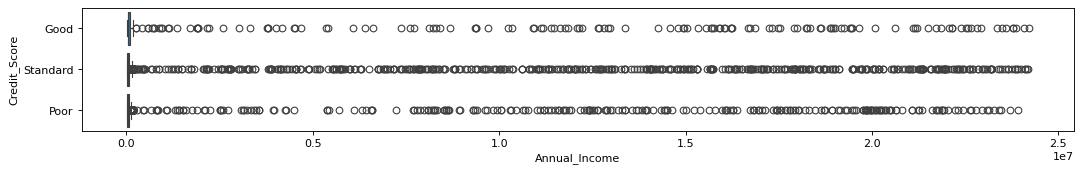

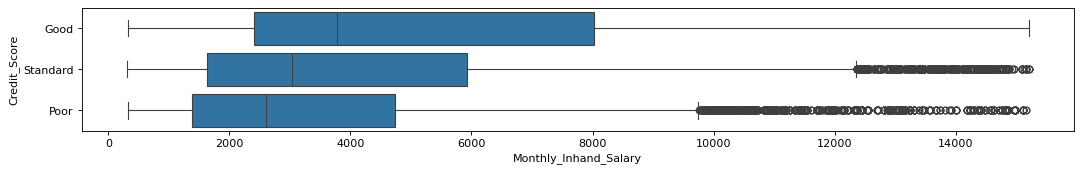

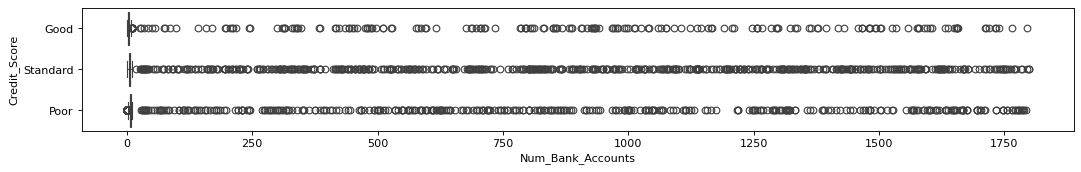

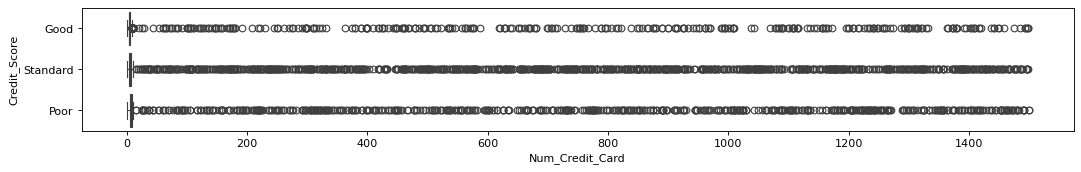

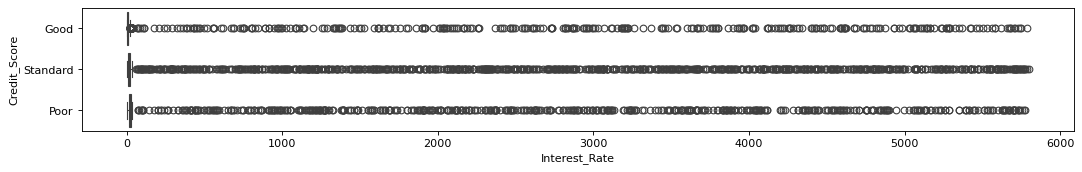

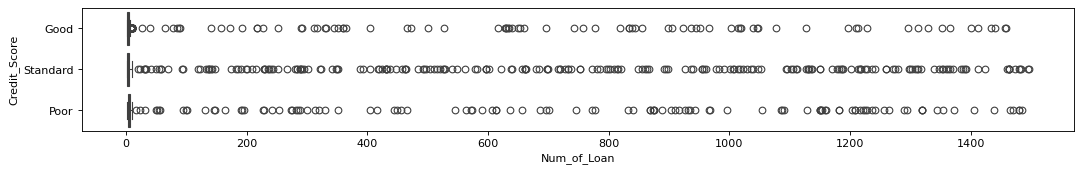

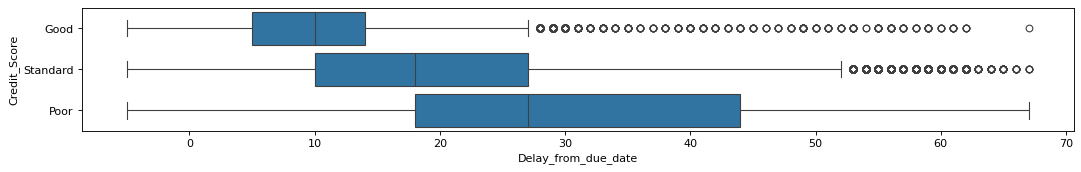

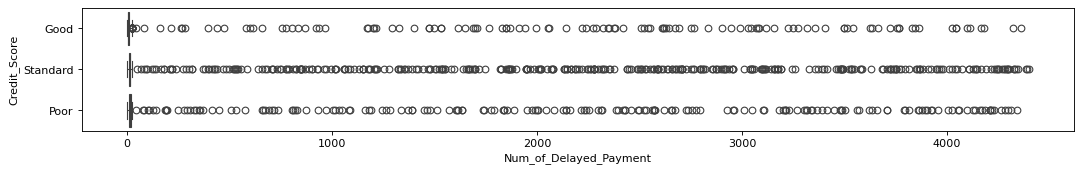

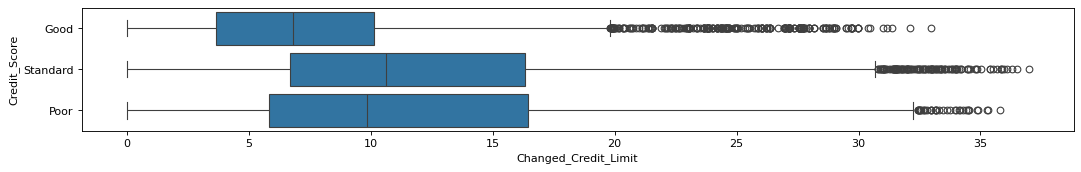

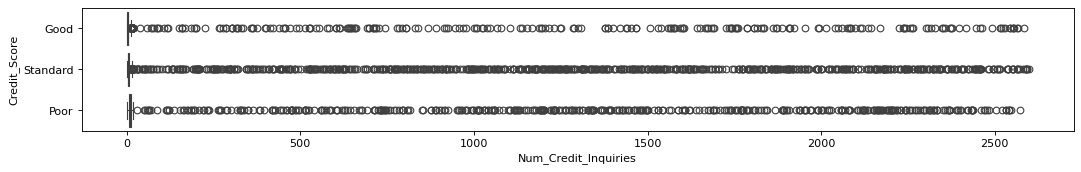

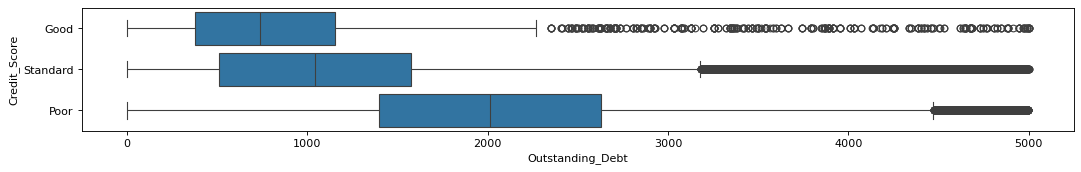

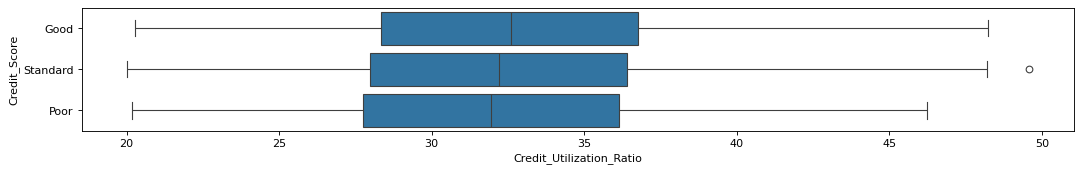

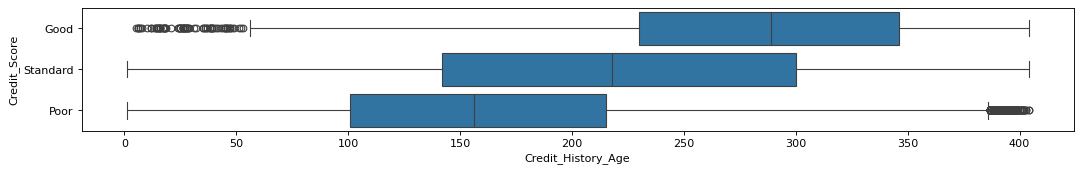

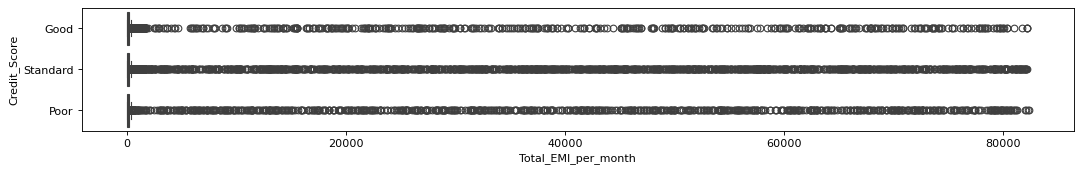

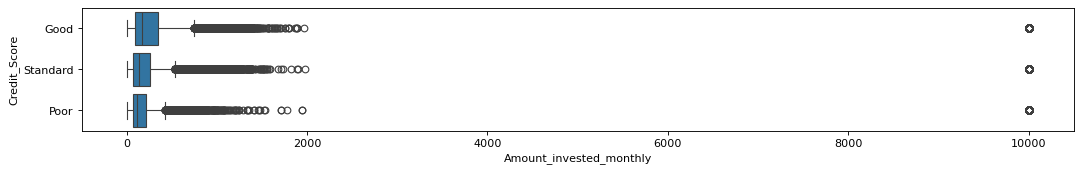

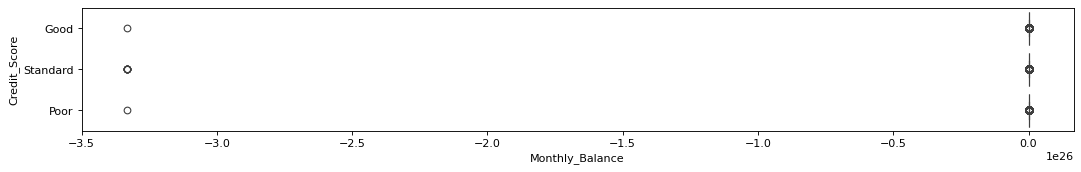

In [602]:
for ax, col in enumerate(num_cols):
    plt.figure(figsize=(16, 2), dpi=80)
    sns.boxplot(x = df[col], y=df['Credit_Score'], data = df, orient='h')
    plt.show()

In [603]:
def replace_with_thresholds(data, col):
    lower_limit, upper_limit = outlier_thresholds(data, col)

    data.loc[(data[col] < lower_limit), col] = lower_limit
    data.loc[(data[col] > upper_limit), col] = upper_limit

for col in num_cols:
    replace_with_thresholds(df, col)

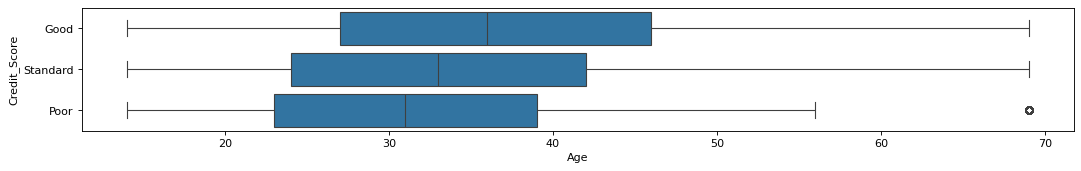

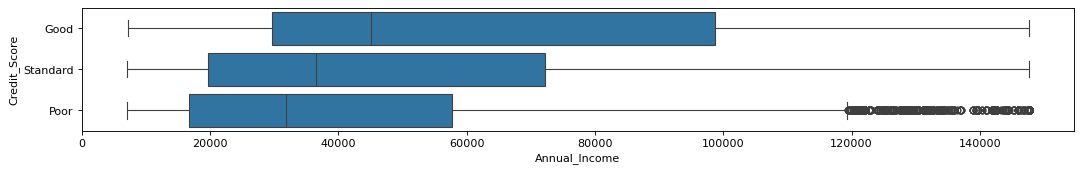

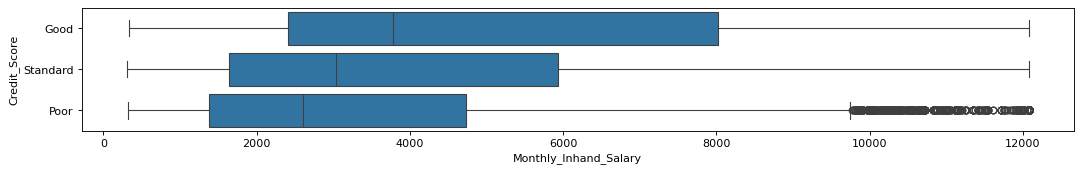

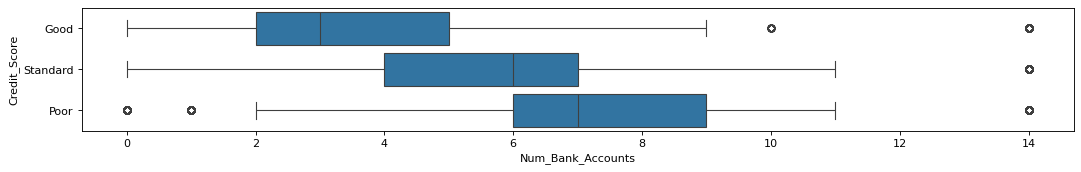

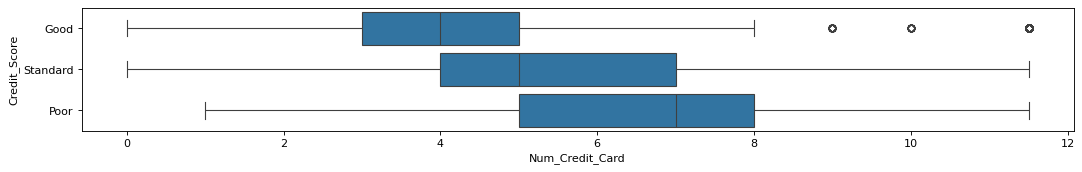

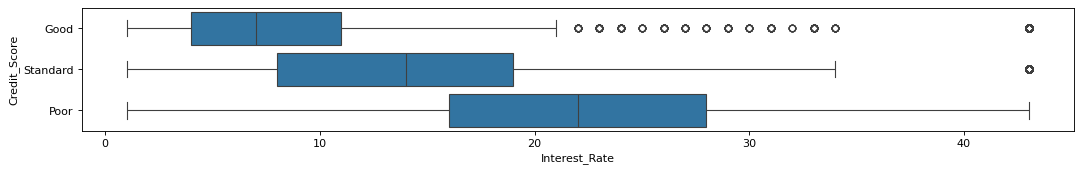

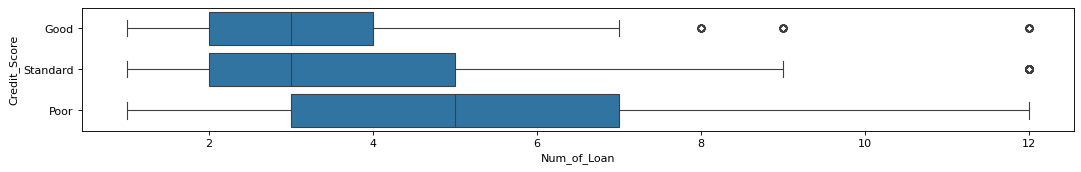

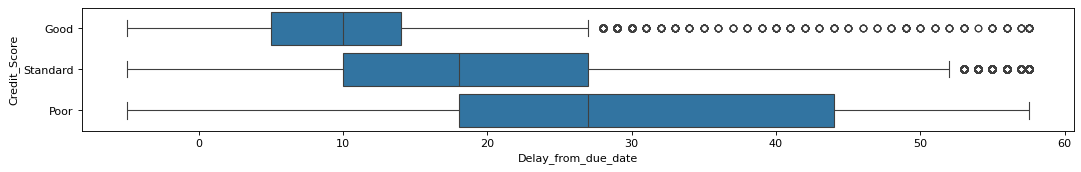

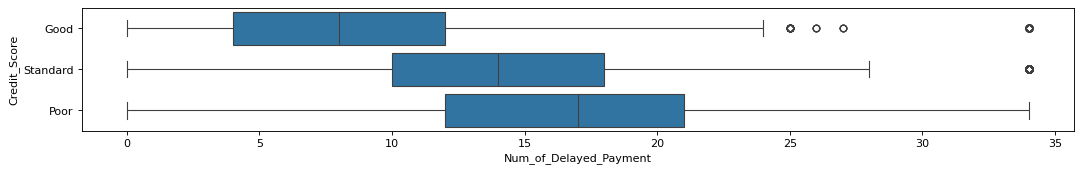

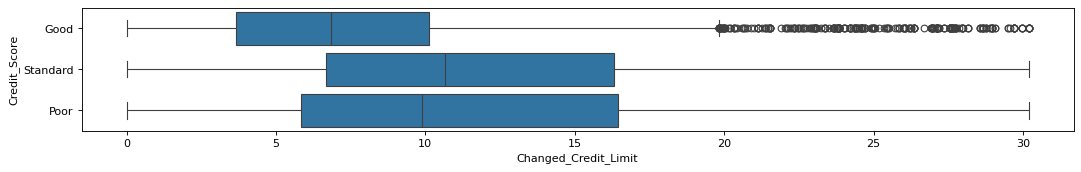

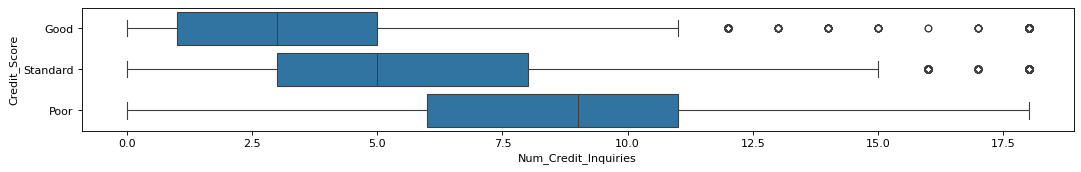

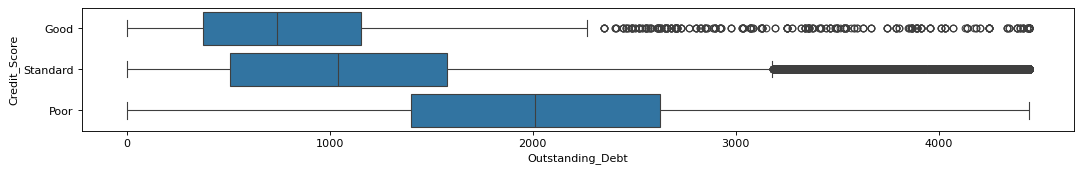

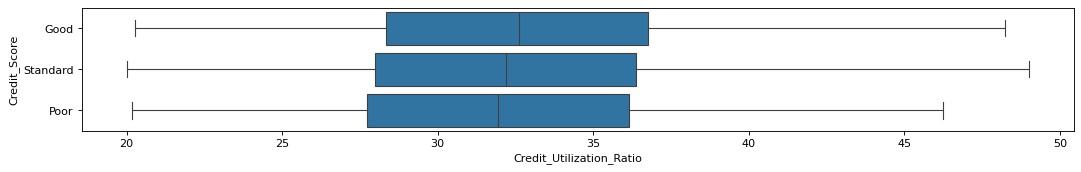

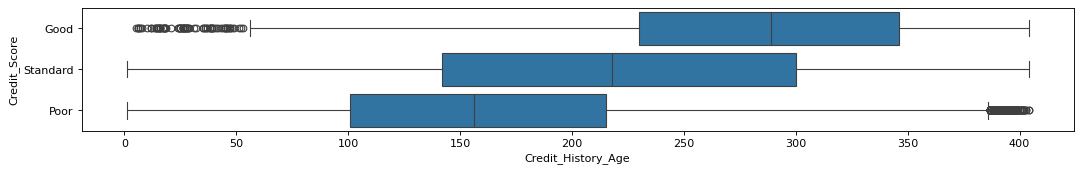

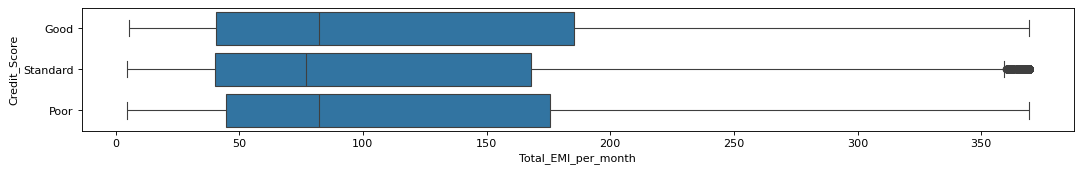

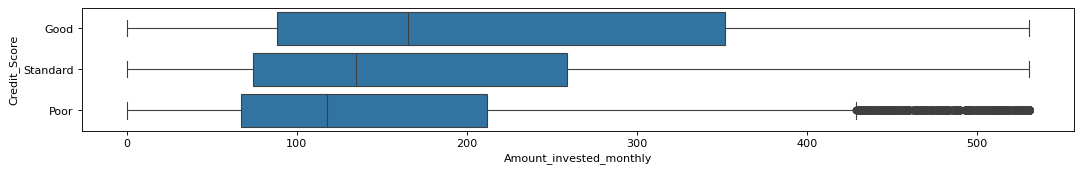

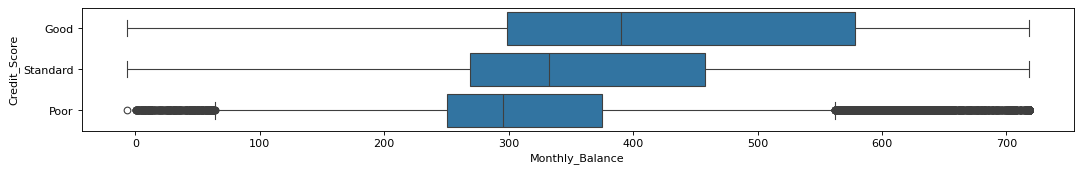

In [604]:
for ax, col in enumerate(num_cols):
    plt.figure(figsize=(16, 2), dpi=80)
    sns.boxplot(x = df[col], y=df['Credit_Score'], data = df, orient='h')
    plt.show()

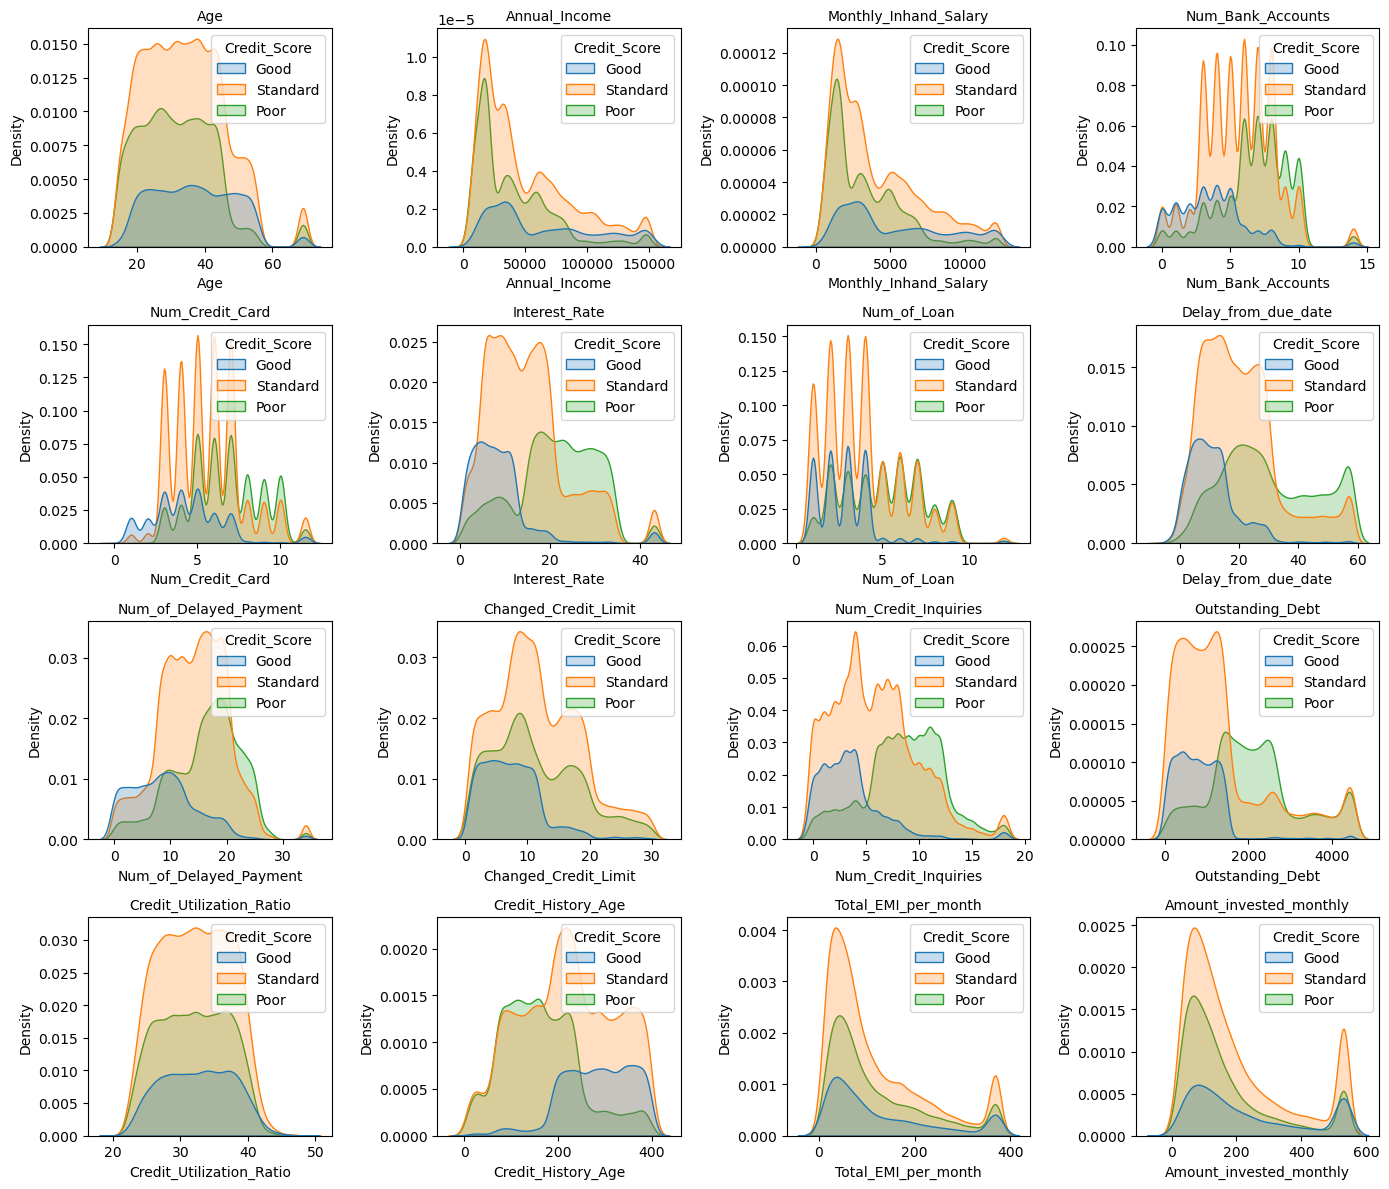

In [605]:
plt.figure(figsize=(14, 12))

for ax, col in enumerate(num_cols[:-1]):
    plt.subplot(4, 4, ax + 1)
    plt.title(col, fontsize=10)
    sns.kdeplot(x=df[col], shade=True, hue=df['Credit_Score'])

plt.tight_layout()
plt.show()

In [606]:
label_map = {
    'Poor': 0,
    'Standard': 1,
    'Good': 2
}

df['Credit_Score'] = df['Credit_Score'].map(label_map)

df['Credit_Score'].value_counts()

Credit_Score
1    46546
0    27662
2    14384
Name: count, dtype: int64

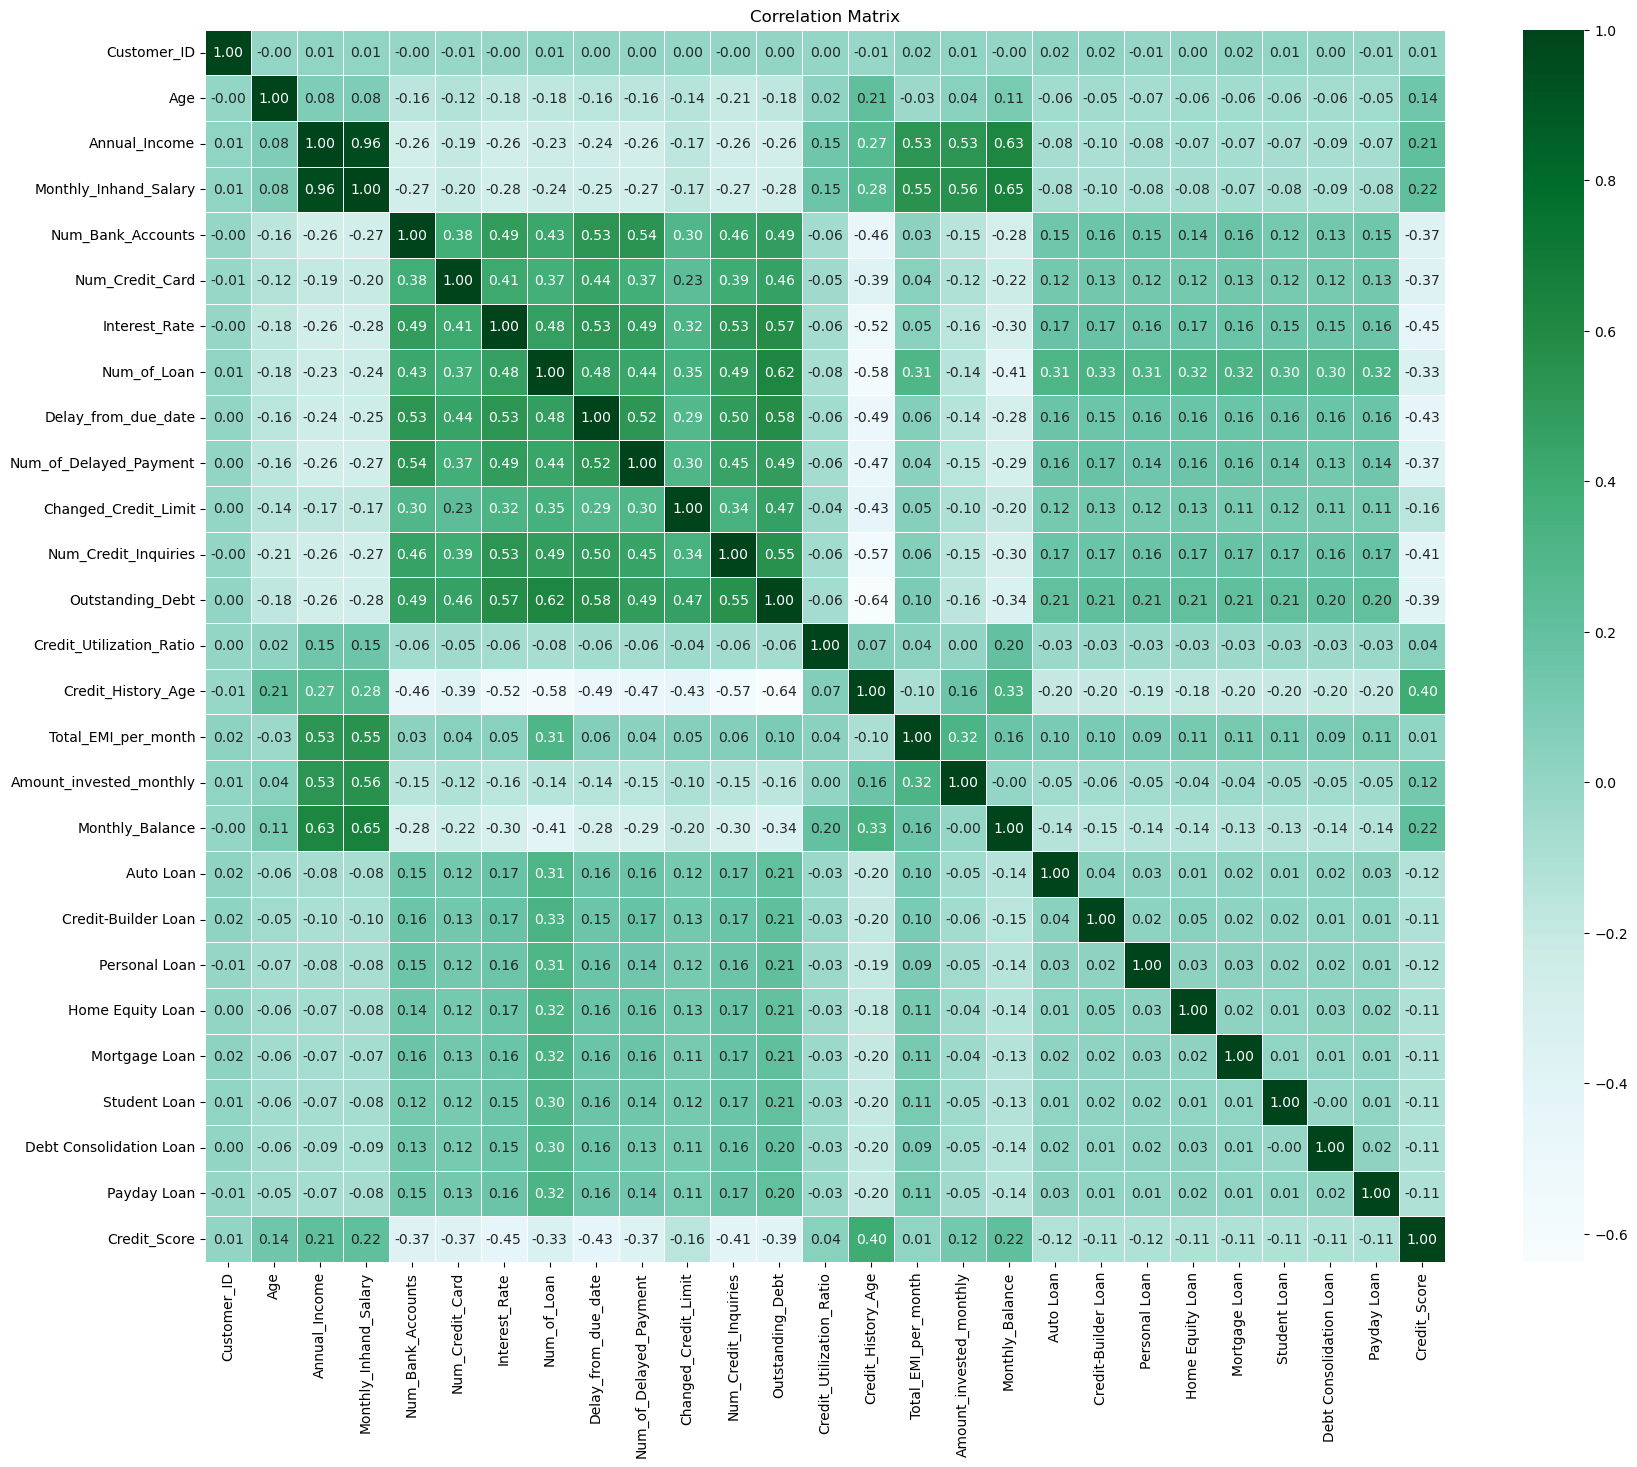

In [607]:
corr_matrix = df.select_dtypes(include=['float64', 'int64']).corr()

plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, annot=True, cmap='BuGn', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix')
plt.show()

In [608]:
df.sample(10)

,Customer_ID,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,...,Monthly_Balance,Auto Loan,Credit-Builder Loan,Personal Loan,Home Equity Loan,Mortgage Loan,Student Loan,Debt Consolidation Loan,Payday Loan,Credit_Score
26896,48041,January,20.0,Engineer,147584.555,12073.911250,3.0,7.0,11,3.0,...,717.804113,1,1,1,0,0,0,0,0,0
21227,2531,April,14.0,Developer,44756.640,3611.720000,10.0,6.0,19,6.0,...,134.105935,0,1,0,1,0,1,1,1,1
70029,43896,June,33.0,Manager,69061.000,5518.083333,8.0,11.5,17,7.0,...,401.621971,1,1,0,0,1,1,0,0,1
33642,49588,March,24.0,Teacher,128675.760,10471.980000,4.0,4.0,6,2.0,...,658.229785,0,1,0,0,0,0,0,0,2
1583,35403,August,52.0,Doctor,110786.640,9299.220000,5.0,7.0,5,3.0,...,85.439713,1,0,1,0,0,0,0,1,1
39980,48716,May,19.0,Lawyer,61778.700,4955.225000,7.0,4.0,18,4.0,...,155.643091,1,0,1,1,0,0,1,0,1
53661,11682,June,45.0,Architect,20318.970,1463.247500,3.0,3.0,17,6.0,...,178.507473,1,1,1,0,0,0,1,1,1
9005,36050,June,27.0,Mechanic,64720.900,5559.408333,4.0,4.0,2,3.0,...,523.864052,0,0,1,1,0,0,0,1,1
77886,44565,July,43.0,Lawyer,30564.960,2263.080000,7.0,6.0,9,1.0,...,245.010895,0,0,0,0,0,0,1,0,1
32670,5789,July,20.0,Musician,8637.095,644.757917,5.0,7.0,14,4.0,...,290.029641,0,0,1,1,0,0,0,0,1


In [609]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols

['Month',
 'Occupation',
 'Credit_Mix',
 'Payment_of_Min_Amount',
 'Payment_Behaviour']

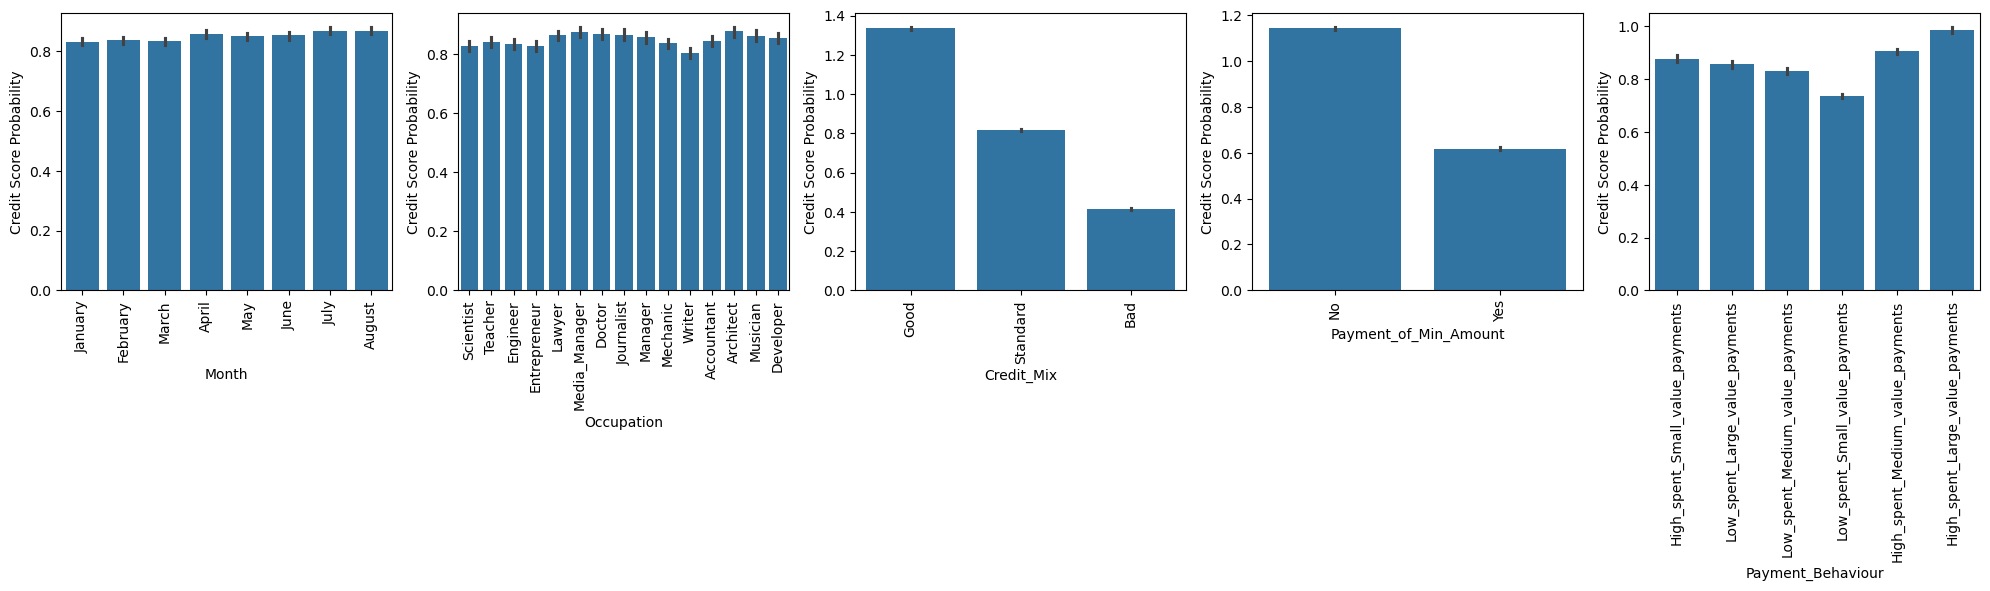

In [610]:
plt.figure(figsize=(20, 6))

for i, col in enumerate(cat_cols, start=1):
    plt.subplot(1, len(cat_cols), i)
    g = sns.barplot(x=col, y='Credit_Score', data=df)
    g.set_ylabel('Credit Score Probability')
    g.set_xticklabels(g.get_xticklabels(), rotation=90)

plt.tight_layout()
plt.show()

In [611]:
q_test_cols = ['Month', 'Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']

test_df = df[q_test_cols]
test_df['Credit_Score'] = df['Credit_Score']

test_df

,Month,Occupation,Credit_Mix,Payment_of_Min_Amount,Payment_Behaviour,Credit_Score
0,January,Scientist,Good,No,High_spent_Small_value_payments,2
1,February,Scientist,Good,No,Low_spent_Large_value_payments,2
2,March,Scientist,Good,No,Low_spent_Medium_value_payments,2
3,April,Scientist,Good,No,Low_spent_Small_value_payments,2
4,May,Scientist,Good,No,High_spent_Medium_value_payments,2
...,...,...,...,...,...,...
99995,April,Mechanic,Good,No,High_spent_Large_value_payments,0
99996,May,Mechanic,Good,No,High_spent_Medium_value_payments,0
99997,June,Mechanic,Good,No,High_spent_Large_value_payments,0
99998,July,Mechanic,Good,No,Low_spent_Large_value_payments,1


In [612]:
from scipy import stats

def chi_square_test(data, col1, col2='Credit_Score'):
    occ = data[[col1, col2]]
    table = pd.crosstab(index=occ[col1], columns=occ[col2])

    t, p, sd, expected = stats.chi2_contingency(table)

    return t, p

In [613]:
cols, values, p_values = [], [], []

for col in test_df.columns[:-1].tolist():
    cols.append(col)
    t, p = chi_square_test(test_df, col)
    values.append(round(t, 2))
    p_values.append(round(p, 2))

chi_df = pd.DataFrame({
    'Variable': cols,
    'Value': values,
    'Pvalue': p_values
})

chi_df = chi_df.sort_values(by='Value', ascending=False)
chi_df.style.bar('Value').background_gradient('Blues', subset='Value')

,Variable,Value,Pvalue
2,Credit_Mix,36275.530000,0.000000
3,Payment_of_Min_Amount,15380.350000,0.000000
4,Payment_Behaviour,1442.730000,0.000000
1,Occupation,175.220000,0.000000
0,Month,171.880000,0.000000


In [614]:
df.drop(['Month', 'Occupation'], axis=1, inplace=True)

In [615]:
df_numeric = df.select_dtypes(include=['int', 'float'])
df_numeric.columns

Index(['Customer_ID', 'Age', 'Annual_Income', 'Monthly_Inhand_Salary',
       'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio',
       'Credit_History_Age', 'Total_EMI_per_month', 'Amount_invested_monthly',
       'Monthly_Balance', 'Auto Loan', 'Credit-Builder Loan', 'Personal Loan',
       'Home Equity Loan', 'Mortgage Loan', 'Student Loan',
       'Debt Consolidation Loan', 'Payday Loan', 'Credit_Score'],
      dtype='object')

In [616]:
len(df_numeric.columns)

27

In [617]:
cols_to_drop = [
    'Auto Loan', 'Credit-Builder Loan', 'Personal Loan',
    'Home Equity Loan', 'Mortgage Loan', 'Student Loan',
    'Debt Consolidation Loan', 'Payday Loan'
]

df_numeric.drop(cols_to_drop, axis=1, inplace=True)

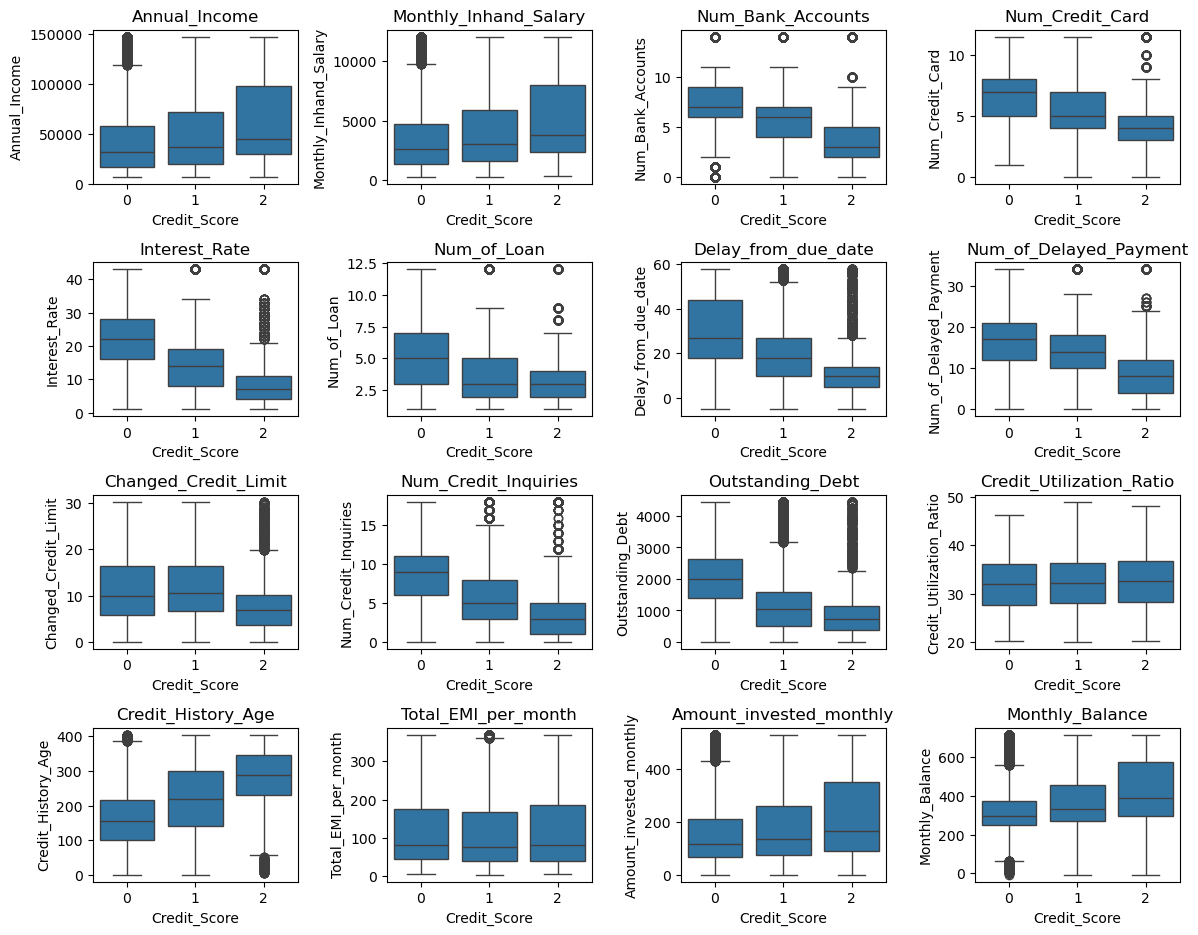

In [618]:
plt.figure(figsize=(12, 16))

for ax, col in enumerate(df_numeric.columns[2:-1]):
    plt.subplot(7, 4, ax + 1)
    plt.title(col)
    sns.boxplot(x='Credit_Score', y=col, data=df_numeric)

plt.tight_layout()

In [619]:
import pingouin as pg

def anova_test(data, col1, col2='Credit_Score'):
    df = data[[col1, col2]]
    df_melted = pd.melt(df, id_vars=col2, var_name=col1, value_name='value')
    test = pg.welch_anova(data=df_melted, dv='value', between=col2)

    return test

In [620]:
cols, values, p_values = [], [], []

for col in df_numeric.columns[:-1]:
    cols.append(col)
    test = anova_test(df , col)
    values.append(round(float(test['F'].values), 2))
    p_values.append(round(float(test['p-unc'].values), 2))

anova_df = pd.DataFrame({
    'Variable': cols,
    'Value': values,
    'Pvalue': p_values
})

anova_df = anova_df.sort_values(by='Value', ascending=False)
anova_df.style.bar('Value').background_gradient('Blues', subset='Value')

,Variable,Value,Pvalue
8,Delay_from_due_date,13219.880000,0.000000
6,Interest_Rate,12444.160000,0.000000
12,Outstanding_Debt,12108.610000,0.000000
14,Credit_History_Age,11195.130000,0.000000
11,Num_Credit_Inquiries,10447.870000,0.000000
4,Num_Bank_Accounts,7536.130000,0.000000
9,Num_of_Delayed_Payment,7352.950000,0.000000
7,Num_of_Loan,6957.470000,0.000000
5,Num_Credit_Card,6943.560000,0.000000
10,Changed_Credit_Limit,3629.970000,0.000000


In [621]:
cols_to_drop = anova_df['Variable'][-3:].tolist()

df.drop(cols_to_drop, axis=1, inplace=True)

df.shape

(88592, 27)

In [622]:
df.columns

Index(['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_History_Age', 'Payment_of_Min_Amount',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Auto Loan', 'Credit-Builder Loan', 'Personal Loan', 'Home Equity Loan',
       'Mortgage Loan', 'Student Loan', 'Debt Consolidation Loan',
       'Payday Loan', 'Credit_Score'],
      dtype='object')

In [623]:
features = df.drop('Credit_Score',axis=1)
label = df['Credit_Score']

In [624]:
cat_col = features.select_dtypes(include='object').columns.tolist()
cat_col

['Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']

In [625]:
for col in cat_col:
    print(features[col].value_counts())
    print()

Credit_Mix
Standard    40736
Good        24088
Bad         23768
Name: count, dtype: int64

Payment_of_Min_Amount
Yes    49515
No     39077
Name: count, dtype: int64

Payment_Behaviour
Low_spent_Small_value_payments      25227
High_spent_Medium_value_payments    16993
High_spent_Large_value_payments     13199
Low_spent_Medium_value_payments     12887
High_spent_Small_value_payments     10613
Low_spent_Large_value_payments       9673
Name: count, dtype: int64



In [626]:
cred_mix = {
    'Bad': 0,
    'Standard': 1,
    'Good': 2
}

features['Credit_Mix'] = features['Credit_Mix'].map(cred_mix)

min_pay = {
    'No': 0,
    'Yes': 1,
}

features['Payment_of_Min_Amount'] = features['Payment_of_Min_Amount'].map(min_pay)

In [627]:
for col in cat_col[2:]:
    print(features[col].value_counts())
    print()

Payment_Behaviour
Low_spent_Small_value_payments      25227
High_spent_Medium_value_payments    16993
High_spent_Large_value_payments     13199
Low_spent_Medium_value_payments     12887
High_spent_Small_value_payments     10613
Low_spent_Large_value_payments       9673
Name: count, dtype: int64



In [628]:
features = pd.get_dummies(features, columns=['Payment_Behaviour'], drop_first=True, dtype=int)
features.shape

(88592, 30)

In [629]:
features.head()

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,...,Home Equity Loan,Mortgage Loan,Student Loan,Debt Consolidation Loan,Payday Loan,Payment_Behaviour_High_spent_Medium_value_payments,Payment_Behaviour_High_spent_Small_value_payments,Payment_Behaviour_Low_spent_Large_value_payments,Payment_Behaviour_Low_spent_Medium_value_payments,Payment_Behaviour_Low_spent_Small_value_payments
0,23.0,19114.12,1824.843333,3.0,4.0,3,4.0,3.0,7.0,11.27,...,1,0,0,0,0,0,1,0,0,0
1,23.0,19114.12,1824.843333,3.0,4.0,3,4.0,-1.0,6.5,11.27,...,1,0,0,0,0,0,0,1,0,0
2,23.0,19114.12,1824.843333,3.0,4.0,3,4.0,3.0,7.0,11.27,...,1,0,0,0,0,0,0,0,1,0
3,23.0,19114.12,1824.843333,3.0,4.0,3,4.0,5.0,4.0,6.27,...,1,0,0,0,0,0,0,0,0,1
4,23.0,19114.12,1824.843333,3.0,4.0,3,4.0,6.0,6.5,11.27,...,1,0,0,0,0,1,0,0,0,0


In [630]:
features.info()

<class 'pandas.core.frame.DataFrame'>
Index: 88592 entries, 0 to 99999
Data columns (total 30 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   Age                                                 88592 non-null  float64
 1   Annual_Income                                       88592 non-null  float64
 2   Monthly_Inhand_Salary                               88592 non-null  float64
 3   Num_Bank_Accounts                                   88592 non-null  float64
 4   Num_Credit_Card                                     88592 non-null  float64
 5   Interest_Rate                                       88592 non-null  int64  
 6   Num_of_Loan                                         88592 non-null  float64
 7   Delay_from_due_date                                 88592 non-null  float64
 8   Num_of_Delayed_Payment                              88592 non-null  float64
 9   

In [631]:
float_cols_with_integers = df.select_dtypes(include='float').apply(lambda col: col.apply(lambda x: x.is_integer())).all()
float_cols_to_convert = float_cols_with_integers[float_cols_with_integers].index
float_cols_to_convert

Index(['Num_Bank_Accounts', 'Num_of_Loan'], dtype='object')

In [632]:
features[float_cols_to_convert] = features[float_cols_to_convert].astype(int)

In [633]:
cols = ['Age', 'Credit_History_Age']
features[cols] = features[cols].astype(int)

In [634]:
features.info()

<class 'pandas.core.frame.DataFrame'>
Index: 88592 entries, 0 to 99999
Data columns (total 30 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   Age                                                 88592 non-null  int64  
 1   Annual_Income                                       88592 non-null  float64
 2   Monthly_Inhand_Salary                               88592 non-null  float64
 3   Num_Bank_Accounts                                   88592 non-null  int64  
 4   Num_Credit_Card                                     88592 non-null  float64
 5   Interest_Rate                                       88592 non-null  int64  
 6   Num_of_Loan                                         88592 non-null  int64  
 7   Delay_from_due_date                                 88592 non-null  float64
 8   Num_of_Delayed_Payment                              88592 non-null  float64
 9   